# SAQ Evaluation Plots (CPP Style)

This notebook loads SAQ aggregate CSVs and plots them using the same visual language as `relerr_cpp_plots.ipynb`:

- same font sizes and figure size
- same color and marker palettes
- same grid and spine treatment
- grouped line plots per dataset
- averaged ADC-time plots and Pareto ADC-vs-relerr plots

By default it reads SAQ results from `/mnthdd/cpanourg/2-hdvc/results/saq` and writes figures to `figures_cpp_style/` there.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- Plot style (aligned with relerr_cpp_plots.ipynb) ---
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 40,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 21,
})
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR_CANDIDATES = [
    Path("/mnthdd/cpanourg/2-hdvc/results/saq_clean_timing"),
    Path("/home/cpanourg/projects/2-hdvc/results/saq_clean_timing"),
    Path("/mnthdd/cpanourg/2-hdvc/results/saq"),
    Path("/data/cpanourg/2-hdvc/results/saq"),
    Path("/home/cpanourg/projects/2-hdvc/results/saq"),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), DATA_DIR_CANDIDATES[0])
CSV_PATTERN = "*_SAQ_adc_vs_exact_eval.csv"
FIGURES_DIR = DATA_DIR / "figures_cpp_style"
FIGURE_SAVE_FORMATS = ("pdf", "svg")

METHODS_TO_PLOT = ["SAQ"]
DATASETS_TO_PLOT = ["deep10k", "bigann10k", "gist10k", "msmarco10k", "openai10k"]
NBITS_LABEL = "Bits per dimension"
BPD_SHORT_LABEL = "bpd"
ADC_TIME_COL = "adc_time_s"
ADC_TIME_LABEL = "ADC time (s)"

# Use one fixed SAQ setting for apples-to-apples timing/relerr plots.
PLOT_CAQ_ADJ_RD_LMT = 6
PLOT_SEARCHER_VARS_BOUND_M = 4.0

Y_METRICS = ["relerr"]
Y_METRIC_MAP = {
    "relerr": ("rel_error_mean", "Avg Relative Error"),
    "encoding_time": ("encoding_time_s", "Encoding time (seconds)"),
    "train_time": ("train_time_s", "Training time (seconds)"),
}

X_COLUMNS_TO_PLOT = [
    ("n_centroids", "# of IVF centroids (K)"),
    ("nbits", NBITS_LABEL),
    ("bits_per_vector", "Bits per vector"),
    (ADC_TIME_COL, ADC_TIME_LABEL),
]

ADDITIONAL_PLOTS = [
    ("n_centroids", "# of IVF centroids (K)", ADC_TIME_COL, ADC_TIME_LABEL, "nbits"),
    ("nbits", NBITS_LABEL, ADC_TIME_COL, ADC_TIME_LABEL, "n_centroids"),
]


In [2]:
def load_saq_data(data_dir: Path = DATA_DIR, pattern: str = CSV_PATTERN) -> pd.DataFrame:
    csv_paths = sorted(data_dir.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f"No CSVs matching {pattern!r} found in {data_dir}")

    frames = []
    for path in csv_paths:
        df = pd.read_csv(path)
        if "dataset" not in df.columns:
            df["dataset"] = path.name.split("_")[0]
        if "method" not in df.columns:
            df["method"] = "SAQ"
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    numeric_cols = [
        "nq", "nb", "nb_sample", "dim", "n_subquantizers", "nbits", "bits_per_vector",
        "train_size", "train_time_s", "encoding_time_s", "distance_table_time_s", "cdist_time_s",
        "adc_time_s", "adc_time_s_std", "per_query_us_mean", "per_pair_ns_mean", "rel_error_mean",
        "rel_error_std", "nq_sample", "seed", "n_centroids", "nprobe", "caq_adj_rd_lmt",
        "searcher_vars_bound_m",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[(df["nbits"] != 0.5) & (df["nbits"] != 0.25)].copy()
    df["method"] = df["method"].fillna("SAQ")

    required = ["method", "dataset", "n_centroids", "nbits", "bits_per_vector", ADC_TIME_COL, "rel_error_mean"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in SAQ dataframe: {missing}")
    return df


def build_plot_df(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Select one fixed SAQ setting for clean apples-to-apples plots."""
    df = raw_df.copy()
    if "caq_adj_rd_lmt" in df.columns:
        df = df[df["caq_adj_rd_lmt"] == PLOT_CAQ_ADJ_RD_LMT]
    if "searcher_vars_bound_m" in df.columns:
        df = df[np.isclose(df["searcher_vars_bound_m"], PLOT_SEARCHER_VARS_BOUND_M)]

    group_cols = ["method", "dataset", "n_centroids", "nbits", "bits_per_vector"]
    agg_spec = {
        "rel_error_mean": "mean",
        ADC_TIME_COL: "mean",
    }
    optional_mean_cols = [
        "rel_error_std", "train_time_s", "encoding_time_s", "adc_time_s", "adc_time_s_std",
        "per_query_us_mean", "per_pair_ns_mean", "nb", "nq", "nb_sample", "nq_sample",
        "dim", "train_size",
    ]
    for col in optional_mean_cols:
        if col in raw_df.columns and col not in agg_spec:
            agg_spec[col] = "mean"

    return (
        df.groupby(group_cols, as_index=False)
        .agg(agg_spec)
        .sort_values(["dataset", "n_centroids", "nbits"])
    )


raw_df = load_saq_data(DATA_DIR)
plot_df = build_plot_df(raw_df)

print(f"Using SAQ data from: {DATA_DIR}")
print(f"Filtered to caq_adj_rd_lmt={PLOT_CAQ_ADJ_RD_LMT}, searcher_vars_bound_m={PLOT_SEARCHER_VARS_BOUND_M}")
print("Raw rows per dataset:")
display(raw_df.groupby("dataset").size())
print("Aggregated rows per dataset:")
display(plot_df.groupby("dataset").size())
plot_df.head()


Using SAQ data from: /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing
Filtered to caq_adj_rd_lmt=6, searcher_vars_bound_m=4.0
Raw rows per dataset:


dataset
bigann10k     18
deep10k       18
gist10k       18
msmarco10k    18
openai10k     18
dtype: int64

Aggregated rows per dataset:


dataset
bigann10k     18
deep10k       18
gist10k       18
msmarco10k    18
openai10k     18
dtype: int64

,method,dataset,n_centroids,nbits,bits_per_vector,rel_error_mean,adc_time_s,rel_error_std,train_time_s,encoding_time_s,adc_time_s_std,per_query_us_mean,per_pair_ns_mean,nb,nq,nb_sample,nq_sample,dim,train_size
0,SAQ,bigann10k,64,1.0,128.0,0.033717,1.16355,NaN,0.000018,0.082366,0.035106,1163.55,746.937,10000.0,1000.0,10000.0,1000.0,128.0,10000.0
1,SAQ,bigann10k,64,2.0,256.0,0.024997,1.16208,NaN,0.000018,0.157032,0.027704,1162.08,745.989,10000.0,1000.0,10000.0,1000.0,128.0,10000.0
2,SAQ,bigann10k,64,3.0,384.0,0.013216,1.18502,NaN,0.000018,0.154955,0.024417,1185.02,760.716,10000.0,1000.0,10000.0,1000.0,128.0,10000.0
3,SAQ,bigann10k,64,4.0,512.0,0.006929,1.26299,NaN,0.000018,0.143766,0.030887,1262.99,810.773,10000.0,1000.0,10000.0,1000.0,128.0,10000.0
4,SAQ,bigann10k,64,6.0,768.0,0.001742,1.35063,NaN,0.000018,0.144073,0.032540,1350.63,867.031,10000.0,1000.0,10000.0,1000.0,128.0,10000.0


In [3]:
COLOR_PALETTE = [
    "tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red",
    "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan",
    "tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red",
]

MARKER_PALETTE = [
    "o", "v", "s", "^", "D", "<", ">", "p", "*", "h", "H", "X", "d", "P", "8"
]


def create_dynamic_color_map(unique_values):
    sorted_values = sorted(unique_values)
    return {val: COLOR_PALETTE[i % len(COLOR_PALETTE)] for i, val in enumerate(sorted_values)}


def create_dynamic_marker_map(unique_values):
    sorted_values = sorted(unique_values)
    return {val: MARKER_PALETTE[i % len(MARKER_PALETTE)] for i, val in enumerate(sorted_values)}


def _save_figure(fig, path_pdf: Path, formats=None):
    path_pdf = Path(path_pdf)
    path_pdf.parent.mkdir(parents=True, exist_ok=True)
    formats = tuple(formats) if formats is not None else FIGURE_SAVE_FORMATS
    for ext in formats:
        out = path_pdf.with_suffix(f".{ext}")
        fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved {path_pdf.with_suffix('')}.[{'/'.join(formats)}]")


def set_sci_axes(ax, tick_fontsize=40, offset_fontsize=30, scilimits=(-3, 3)):
    ax.tick_params(labelsize=tick_fontsize)
    x_log = ax.get_xscale() == "log"
    y_log = ax.get_yscale() == "log"

    if not x_log and isinstance(ax.xaxis.get_major_formatter(), ScalarFormatter):
        ax.ticklabel_format(style="scientific", axis="x", scilimits=scilimits)
        ax.xaxis.offsetText.set_fontsize(offset_fontsize)
    if not y_log and isinstance(ax.yaxis.get_major_formatter(), ScalarFormatter):
        ax.ticklabel_format(style="scientific", axis="y", scilimits=scilimits)
        ax.yaxis.offsetText.set_fontsize(offset_fontsize)


def _format_tick_value(x):
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, (float, np.floating)) and float(x).is_integer():
        return str(int(x))
    return str(x)


def _set_discrete_xticks(ax, tick_values, rotation=0, fontsize=34):
    ax.set_xticks(tick_values)
    ax.set_xticklabels(
        [_format_tick_value(x) for x in tick_values],
        rotation=rotation,
        ha="right" if rotation and rotation != 90 else "center",
    )
    ax.tick_params(axis="x", labelsize=fontsize)


def plot_relerr_vs_x(
    df: pd.DataFrame,
    x_col: str,
    x_label: str,
    y_col: str = "rel_error_mean",
    y_label: str = None,
    methods: list = None,
    datasets: list = None,
    group_by: str = None,
    output_dir: Path = None,
):
    if methods is None:
        methods = sorted(df["method"].dropna().unique())
    if datasets is None:
        datasets = sorted(df["dataset"].dropna().unique())
    if output_dir is None:
        output_dir = FIGURES_DIR

    group_aliases = {
        "nbits": "nbits",
        "bits": "nbits",
        "n_centroids": "n_centroids",
        "K": "n_centroids",
        "centroids": "n_centroids",
    }
    if group_by is not None:
        group_col = group_aliases.get(group_by)
        if group_col is None:
            raise ValueError(f"Unsupported group_by={group_by!r}")
    elif x_col == "n_centroids":
        group_col = "nbits"
    elif x_col == "nbits":
        group_col = "n_centroids"
    elif x_col == "bits_per_vector":
        group_col = "n_centroids"
    else:
        group_col = "n_centroids"

    group_label_prefix = f"{BPD_SHORT_LABEL}=" if group_col == "nbits" else "K="
    adc_time_cols = {ADC_TIME_COL, "adc_time_s"}

    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].copy()
            sub = sub.dropna(subset=[x_col, y_col, group_col])
            if sub.empty:
                continue

            unique_group_values = sorted(sub[group_col].unique())
            color_map = create_dynamic_color_map(unique_group_values)
            marker_map = create_dynamic_marker_map(unique_group_values)

            fig, ax = plt.subplots()
            for group_val in unique_group_values:
                group_df = sub[sub[group_col] == group_val].sort_values(x_col)
                ax.plot(
                    group_df[x_col],
                    group_df[y_col],
                    label=f"{group_label_prefix}{_format_tick_value(group_val)}",
                    color=color_map[group_val],
                    marker=marker_map[group_val],
                    markersize=12,
                    linewidth=2,
                    markeredgewidth=2,
                    markeredgecolor="black",
                )

            if y_label is None:
                if y_col == "rel_error_mean":
                    current_y_label = "Avg Relative Error"
                elif y_col == ADC_TIME_COL:
                    current_y_label = ADC_TIME_LABEL
                elif y_col == "encoding_time_s":
                    current_y_label = "Encoding time (seconds)"
                elif y_col == "train_time_s":
                    current_y_label = "Training time (seconds)"
                else:
                    current_y_label = y_col.replace("_", " ").title()
            else:
                current_y_label = y_label

            ax.set_xlabel(x_label, fontsize=40)
            ax.set_ylabel(current_y_label, fontsize=40)
            if y_col == "rel_error_mean" and x_col in {"n_centroids", "nbits"}:
                ax.yaxis.set_label_coords(-0.24 if x_col == "nbits" else -0.18, 0.5)

            if x_col in adc_time_cols:
                ax.set_xscale("log")
            if (sub[y_col] > 0).all():
                ax.set_yscale("log")
            if x_col == "n_centroids":
                ax.set_xscale("log")
                tick_values = sorted(sub[x_col].unique())
                _set_discrete_xticks(ax, tick_values)
            elif x_col in {"nbits", "bits_per_vector"}:
                tick_values = sorted(sub[x_col].unique())
                _set_discrete_xticks(ax, tick_values, fontsize=30)

            set_sci_axes(ax, tick_fontsize=40, offset_fontsize=30)
            ax.grid(alpha=0.8, axis="y", linestyle="--")
            for spine in ax.spines.values():
                spine.set_visible(False)

            if group_col == "nbits":
                ax.legend(
                    frameon=False,
                    loc="center left",
                    bbox_to_anchor=(1.05, 0.5),
                    fontsize=18,
                )
            elif x_col in ["nbits", "bits_per_vector"]:
                ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.05, 0.5))
            else:
                ax.legend(frameon=False, loc="best")

            plt.tight_layout()
            safe_y = y_col.replace("_", "")
            safe_x = x_col.replace("_", "")
            savepath = output_dir / f"{safe_y}_{method.lower()}_{dataset}_{safe_x}.pdf"
            _save_figure(fig, savepath)
            plt.show()
            plt.close(fig)


Plotting Avg Relative Error vs # of IVF centroids (K)
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_deep10k_ncentroids.[pdf/svg]


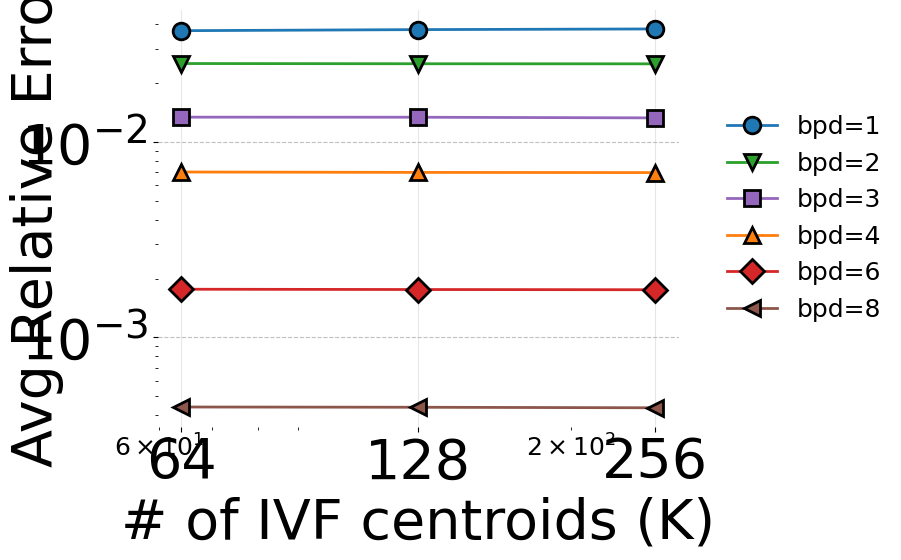

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_bigann10k_ncentroids.[pdf/svg]


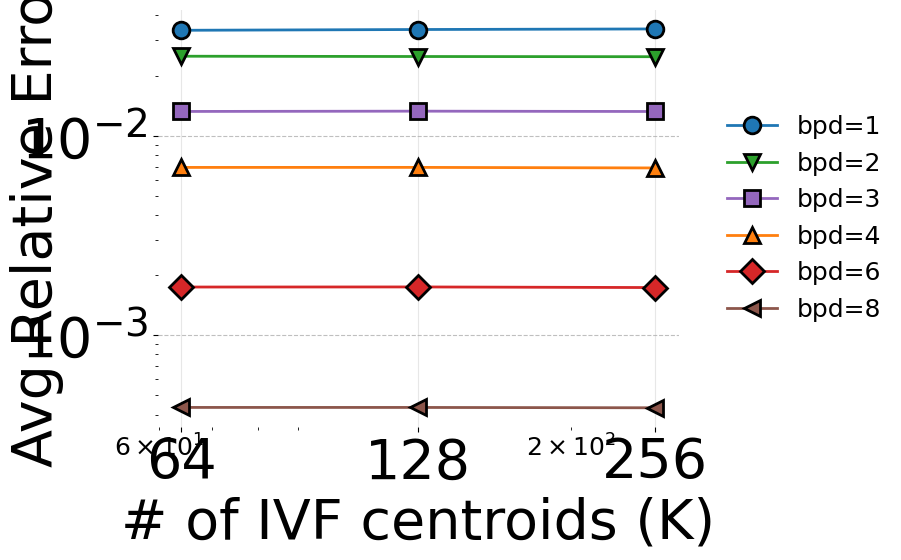

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_gist10k_ncentroids.[pdf/svg]


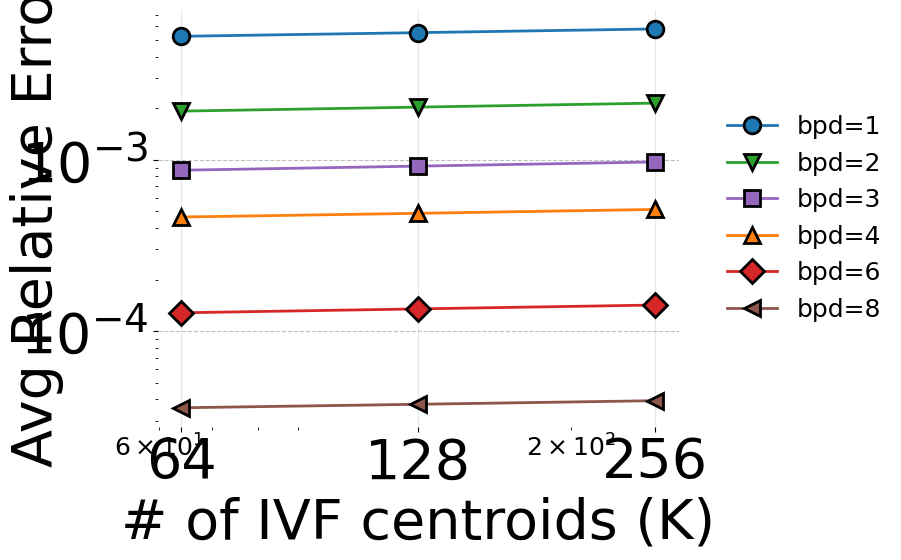

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_msmarco10k_ncentroids.[pdf/svg]


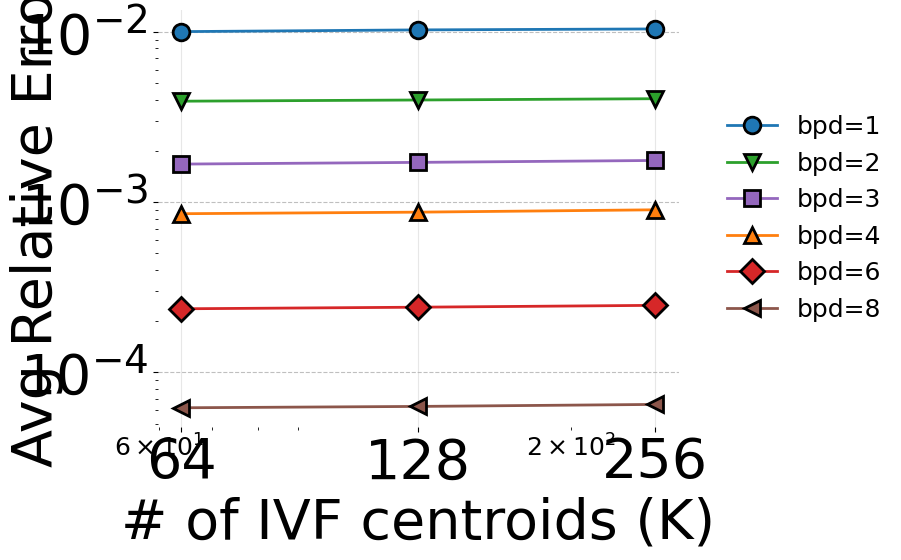

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_openai10k_ncentroids.[pdf/svg]


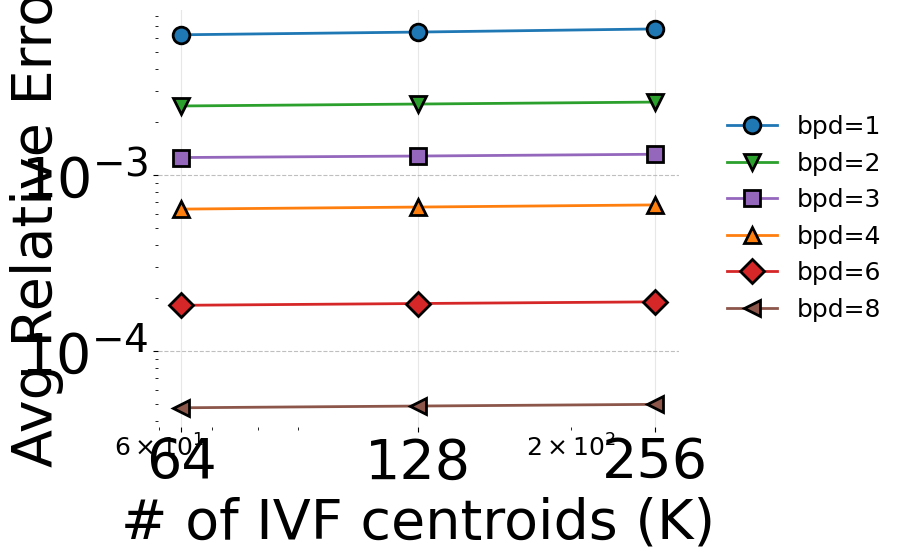

Plotting Avg Relative Error vs Bits per dimension
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_deep10k_nbits.[pdf/svg]


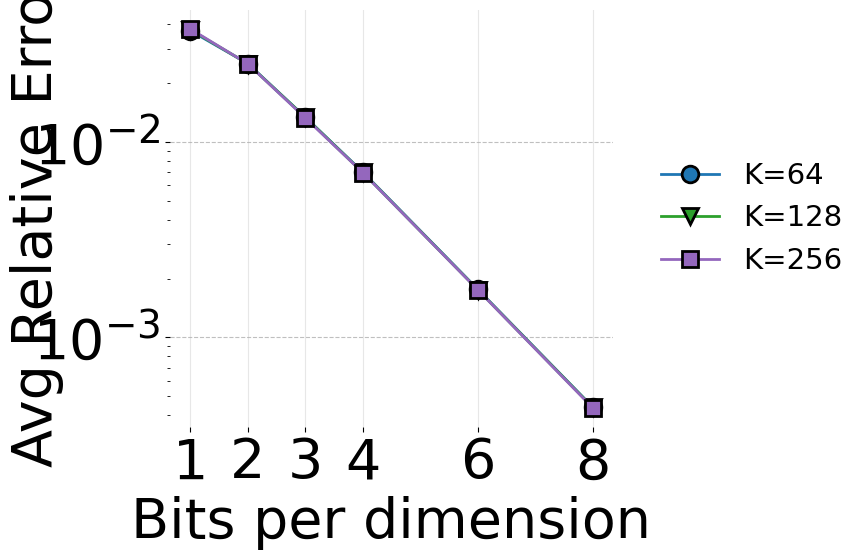

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_bigann10k_nbits.[pdf/svg]


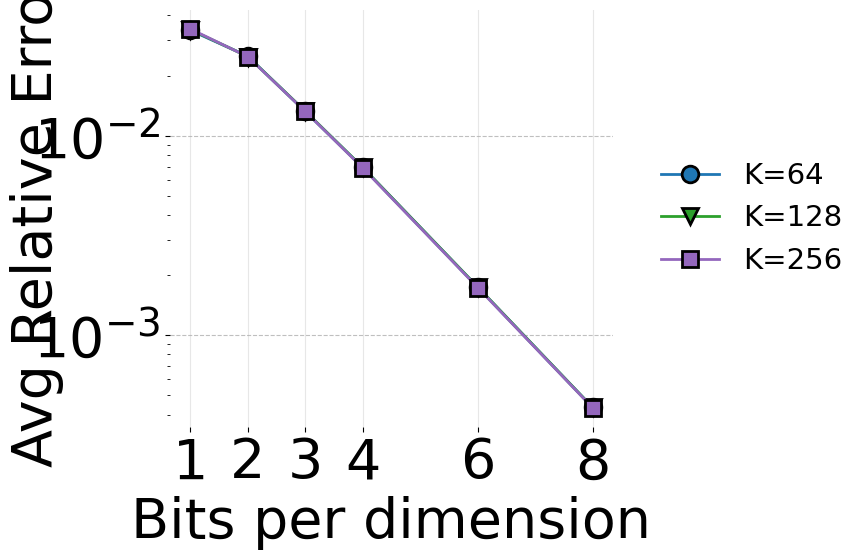

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_gist10k_nbits.[pdf/svg]


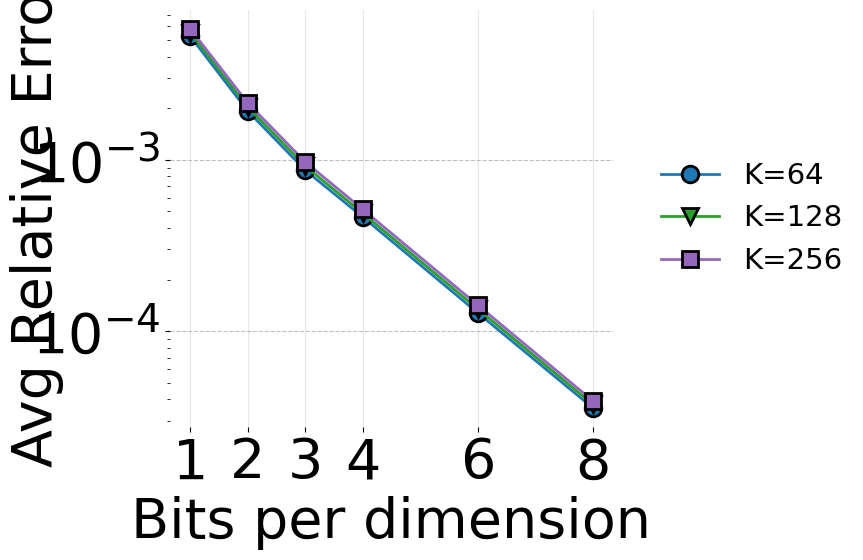

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_msmarco10k_nbits.[pdf/svg]


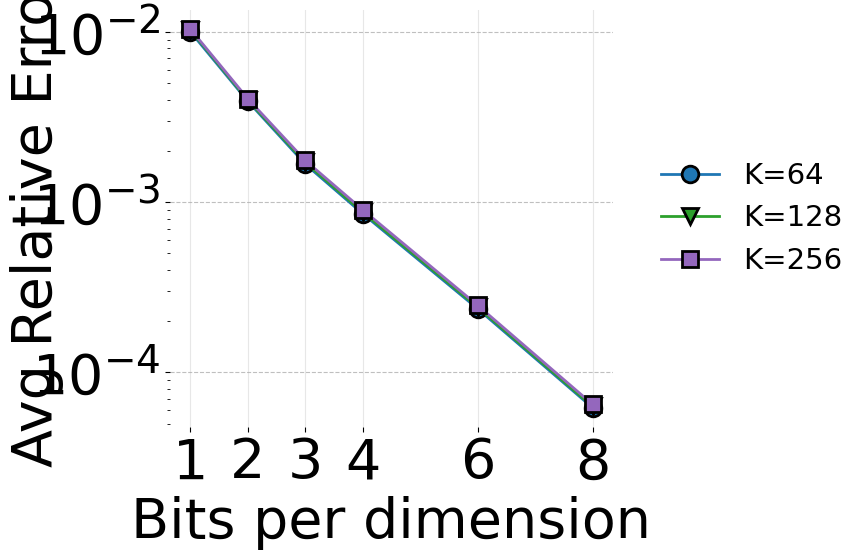

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_openai10k_nbits.[pdf/svg]


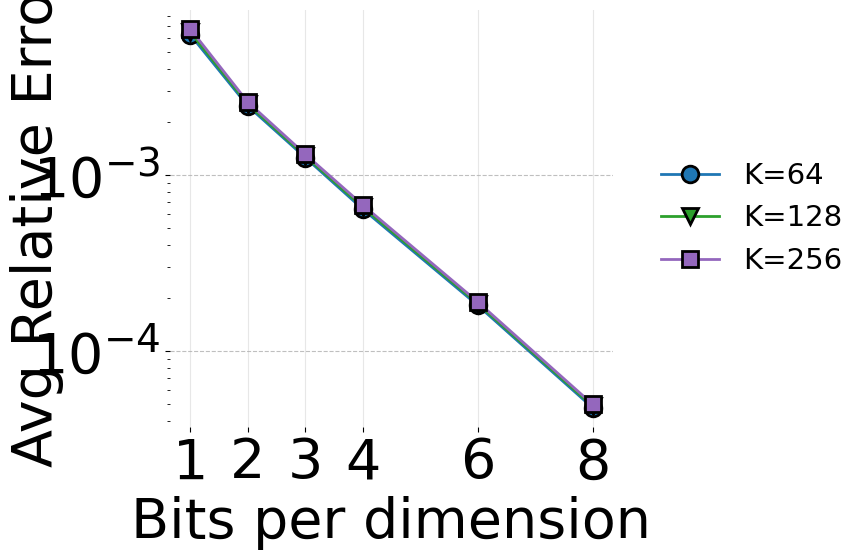

Plotting Avg Relative Error vs Bits per vector
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_deep10k_bitspervector.[pdf/svg]


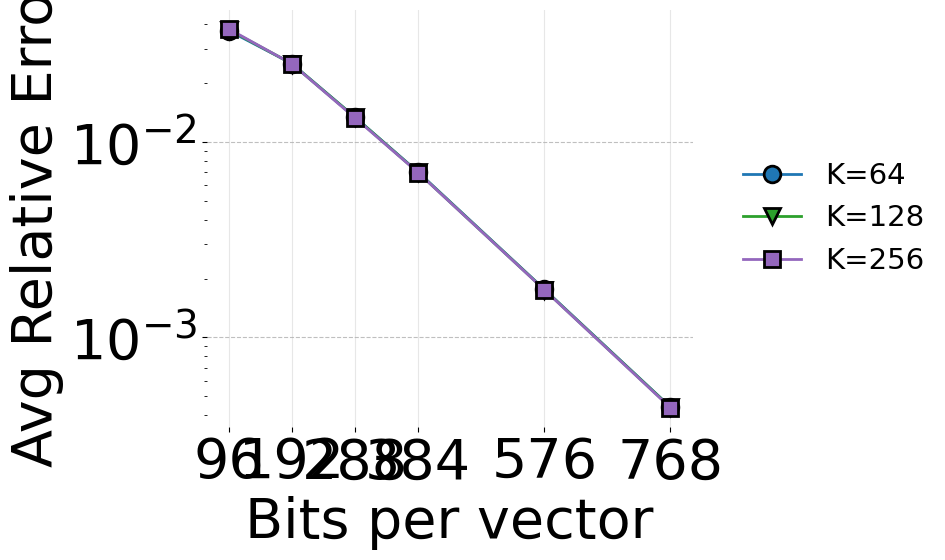

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_bigann10k_bitspervector.[pdf/svg]


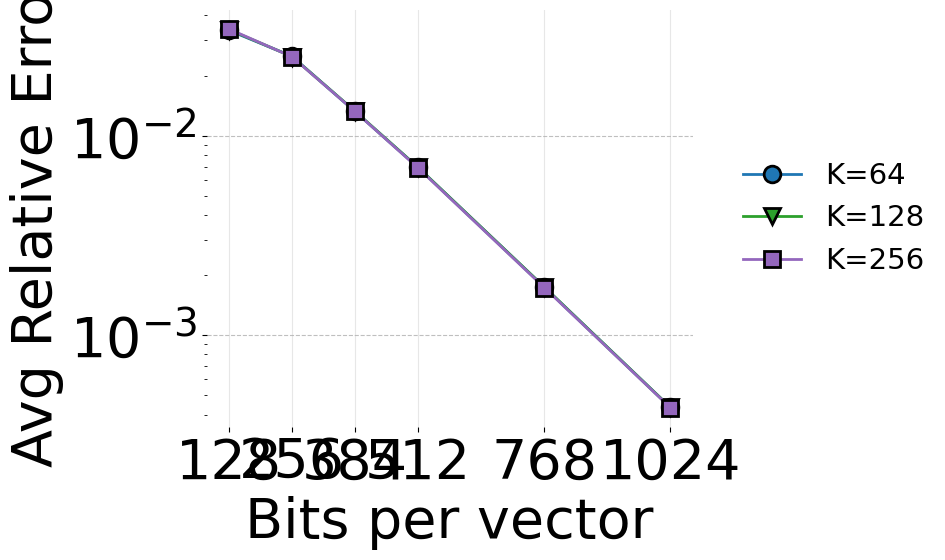

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_gist10k_bitspervector.[pdf/svg]


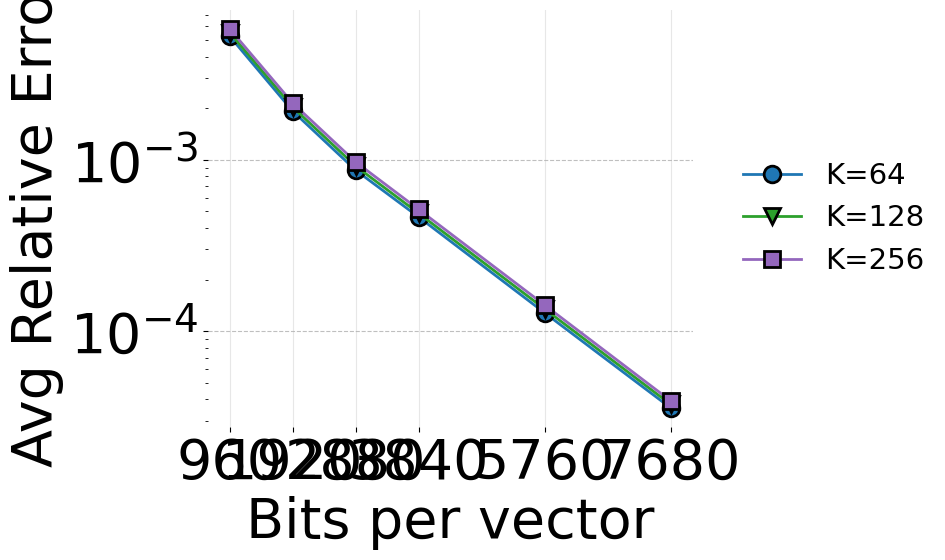

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_msmarco10k_bitspervector.[pdf/svg]


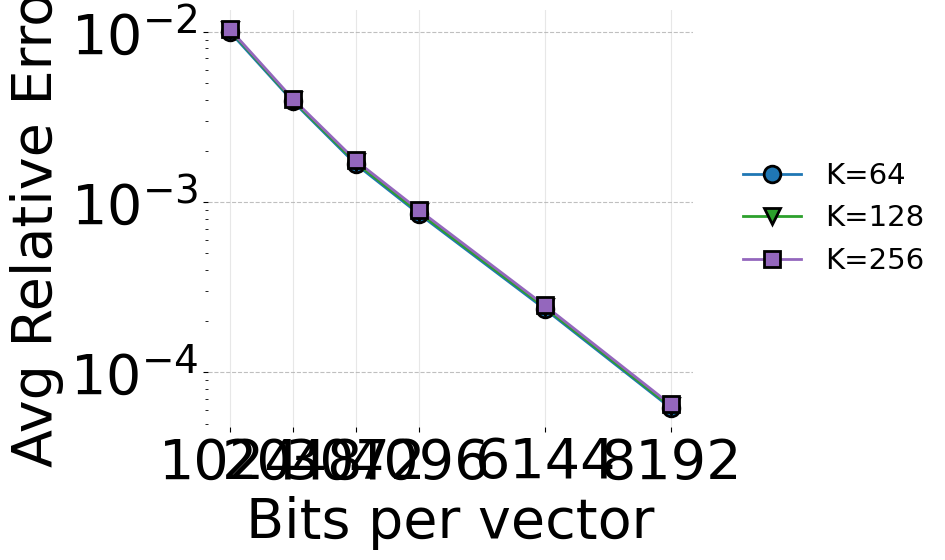

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_openai10k_bitspervector.[pdf/svg]


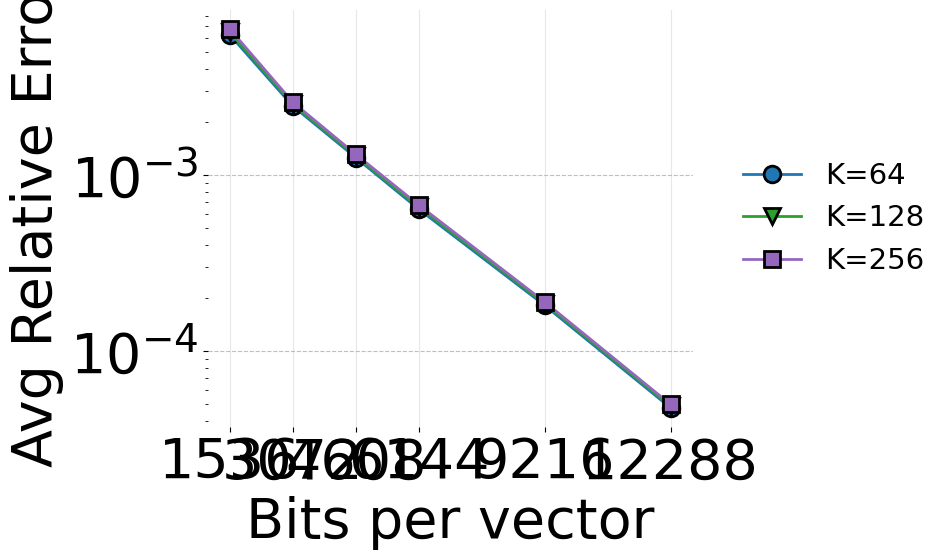

Plotting Avg Relative Error vs ADC time (s)
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_deep10k_adctimes.[pdf/svg]


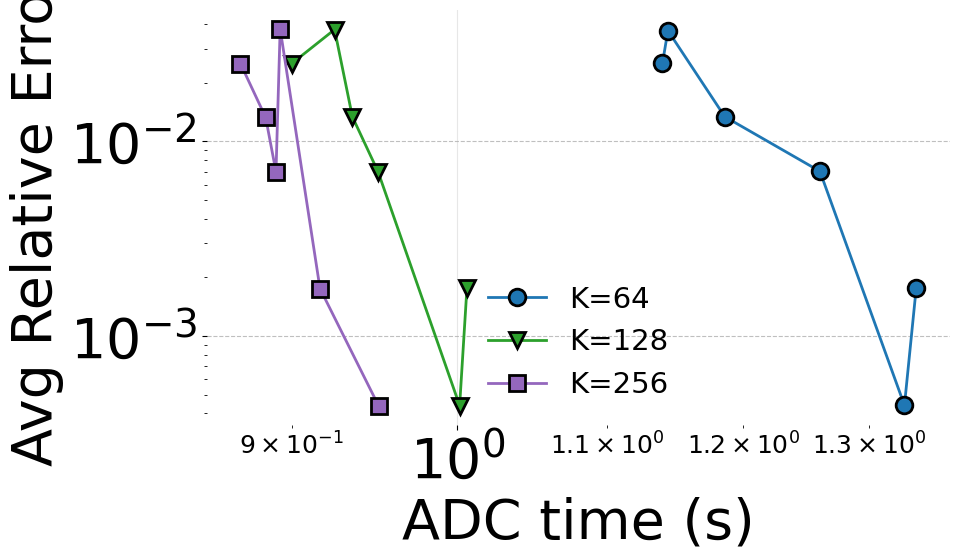

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_bigann10k_adctimes.[pdf/svg]


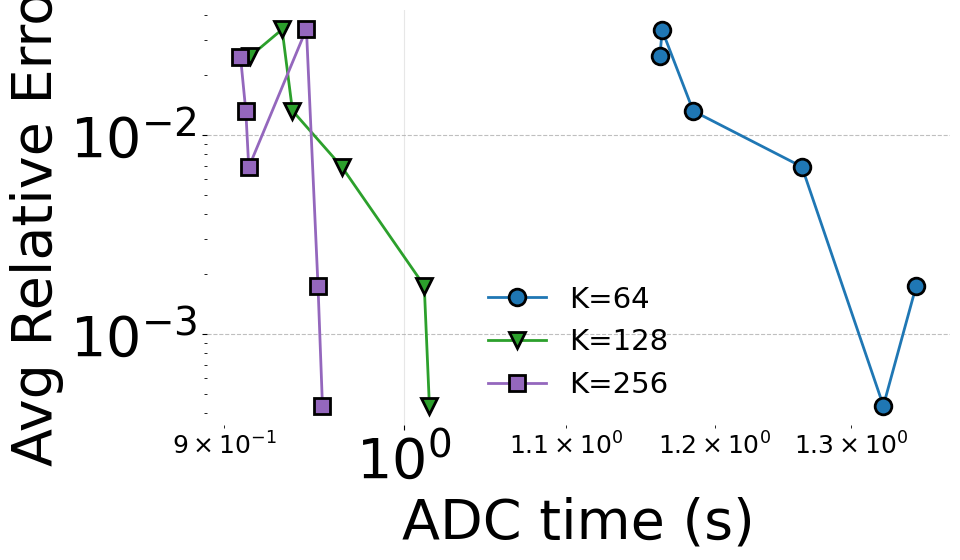

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_gist10k_adctimes.[pdf/svg]


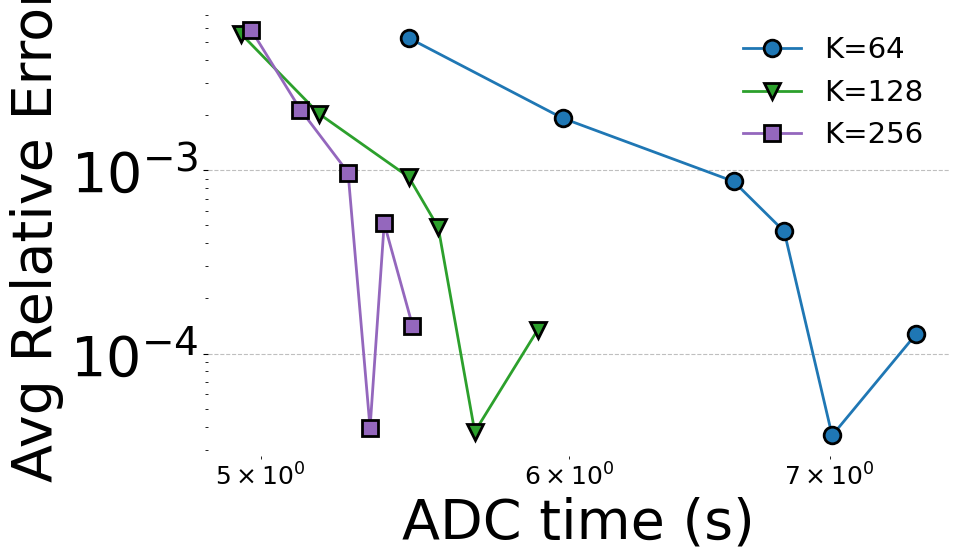

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_msmarco10k_adctimes.[pdf/svg]


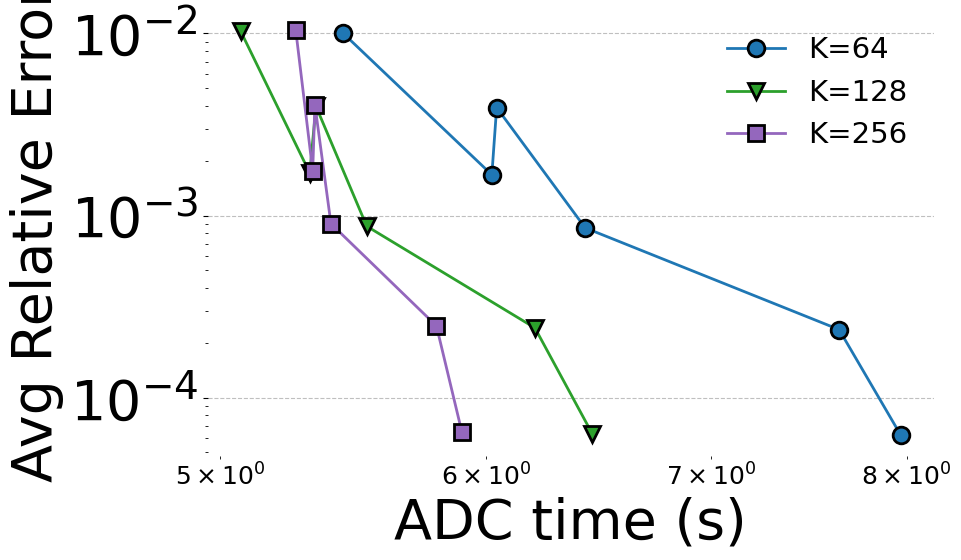

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/relerrormean_saq_openai10k_adctimes.[pdf/svg]


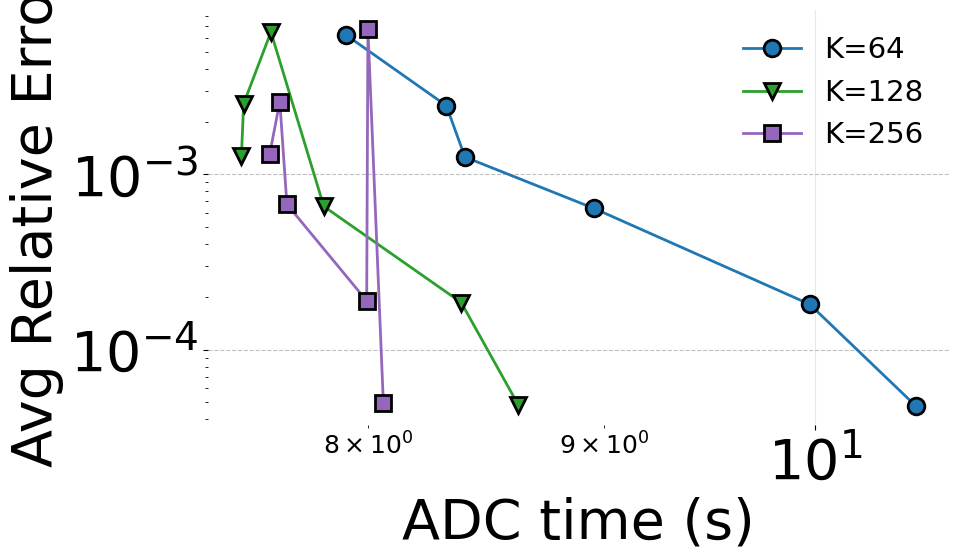

Plotting ADC time (s) vs # of IVF centroids (K) grouped by nbits
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_deep10k_ncentroids.[pdf/svg]


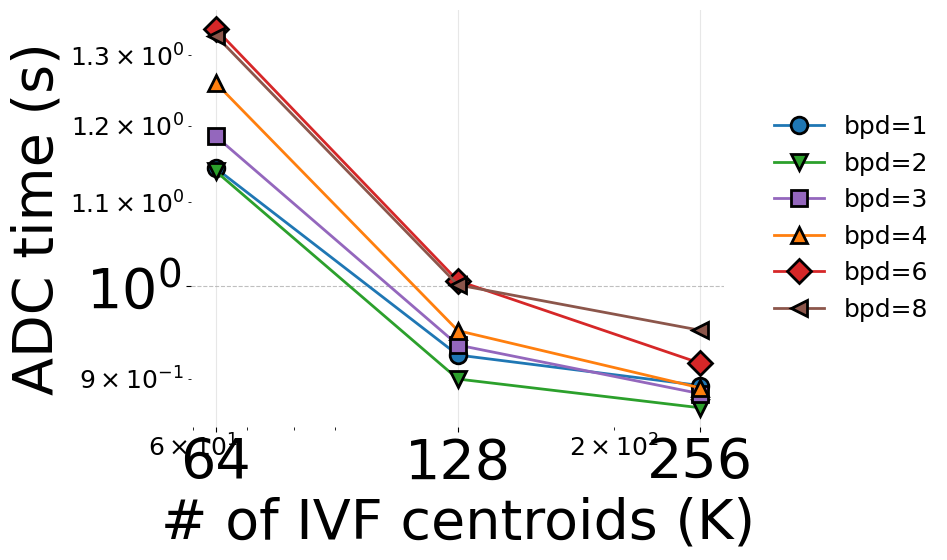

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_bigann10k_ncentroids.[pdf/svg]


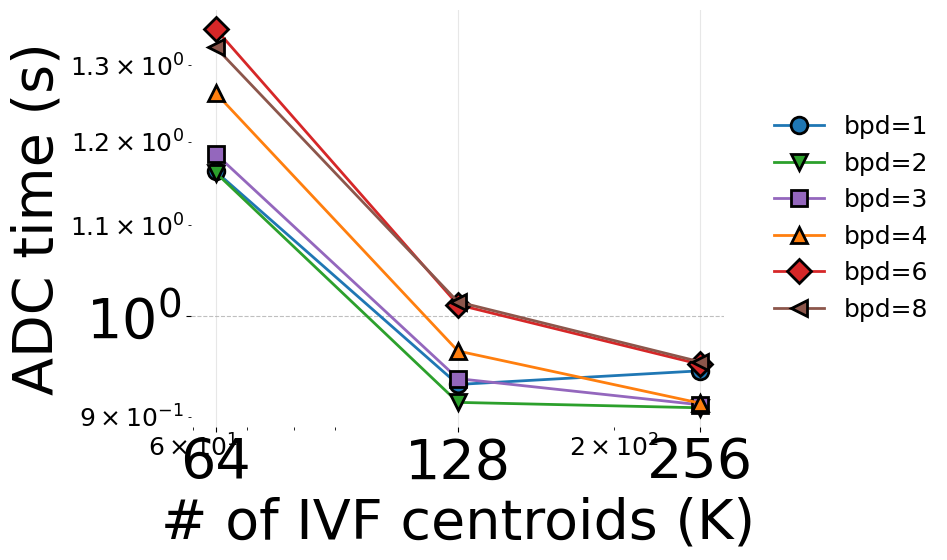

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_gist10k_ncentroids.[pdf/svg]


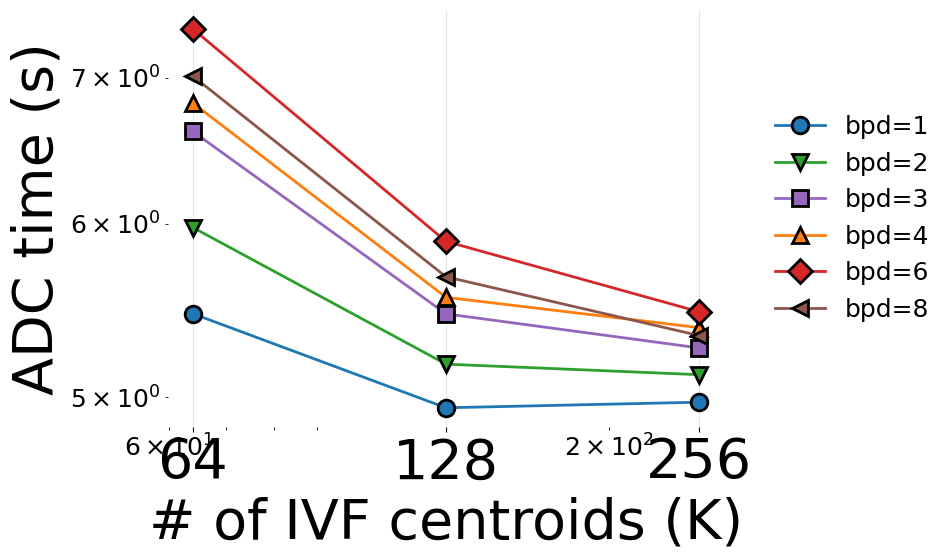

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_msmarco10k_ncentroids.[pdf/svg]


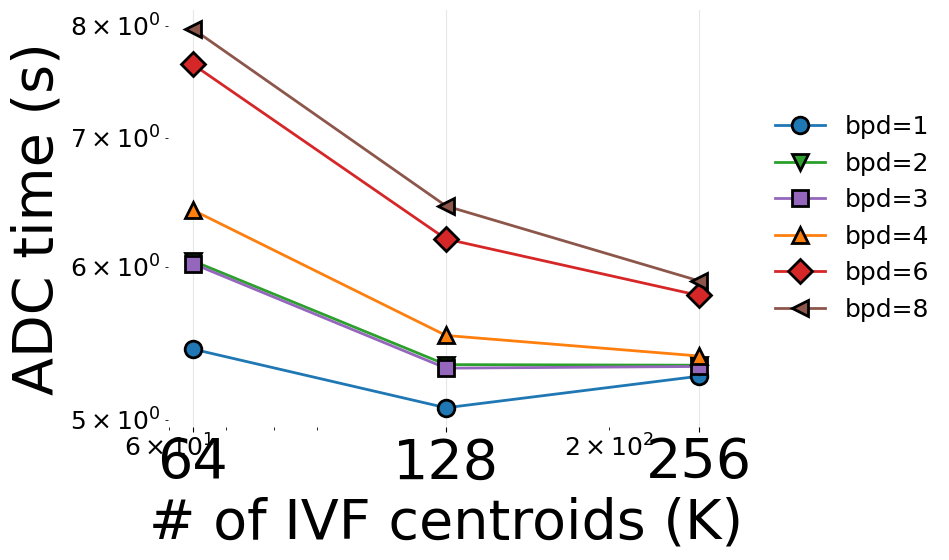

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_openai10k_ncentroids.[pdf/svg]


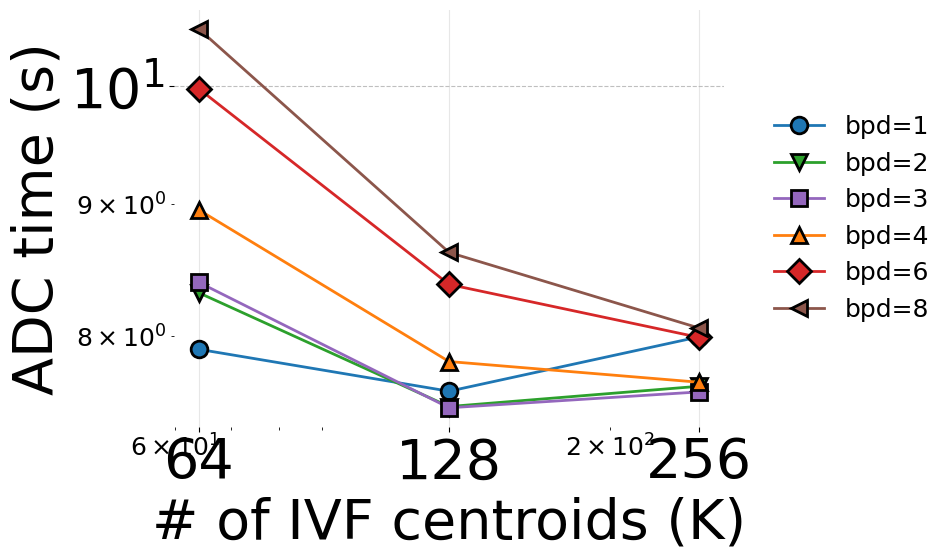

Plotting ADC time (s) vs Bits per dimension grouped by n_centroids
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_deep10k_nbits.[pdf/svg]


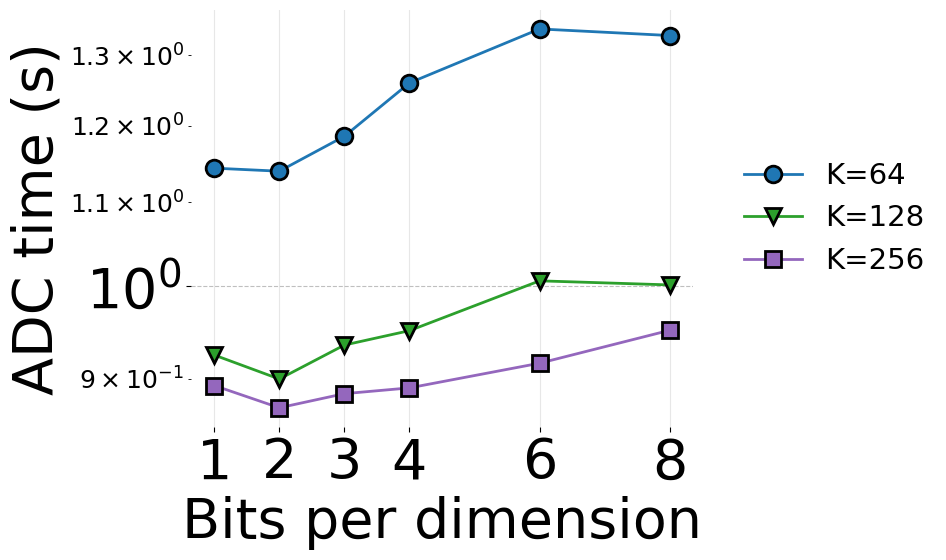

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_bigann10k_nbits.[pdf/svg]


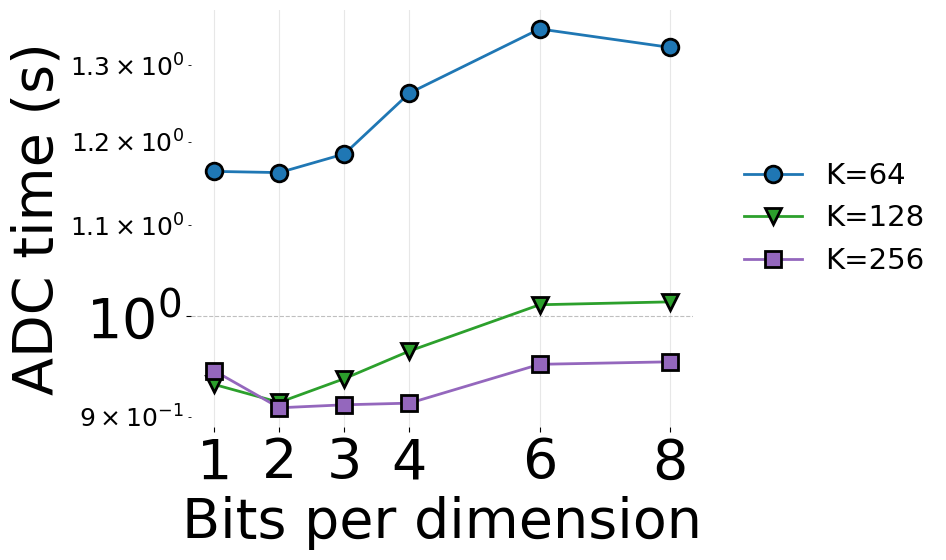

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_gist10k_nbits.[pdf/svg]


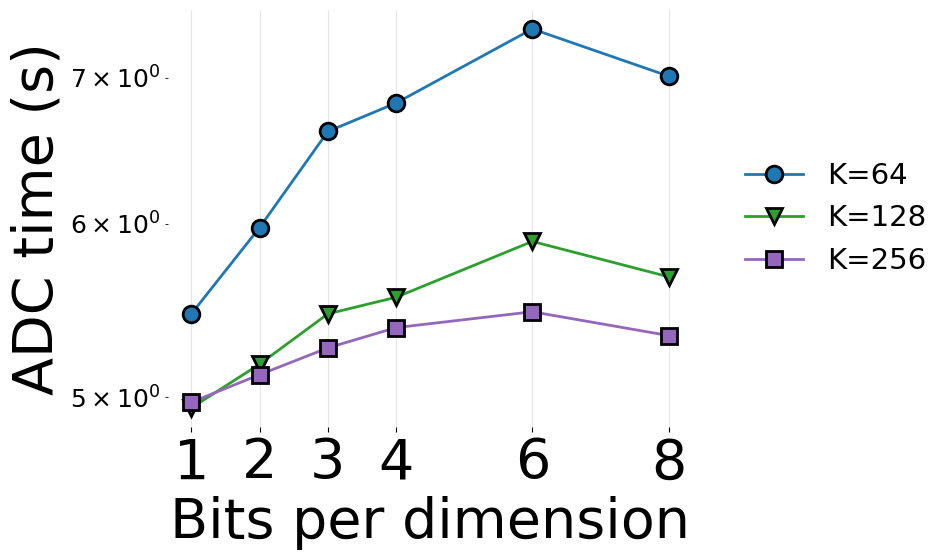

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_msmarco10k_nbits.[pdf/svg]


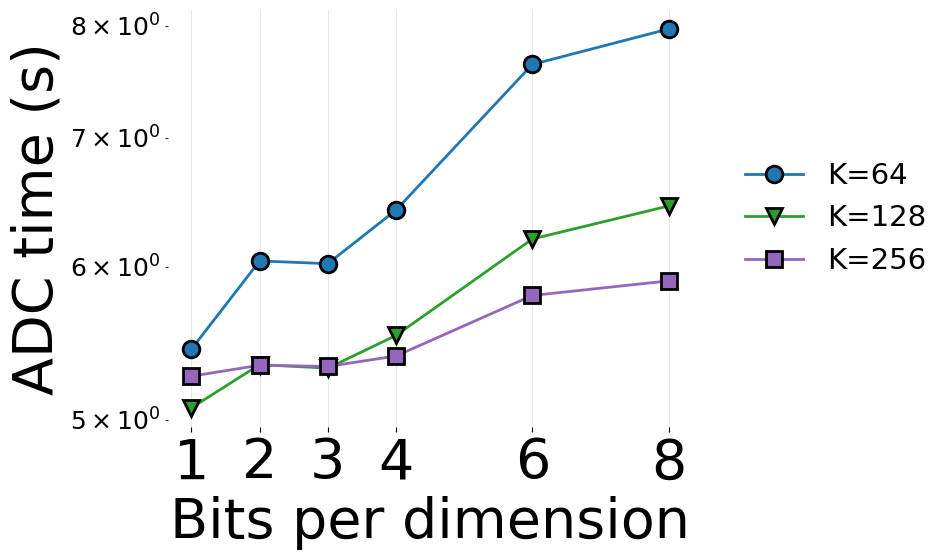

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/adctimes_saq_openai10k_nbits.[pdf/svg]


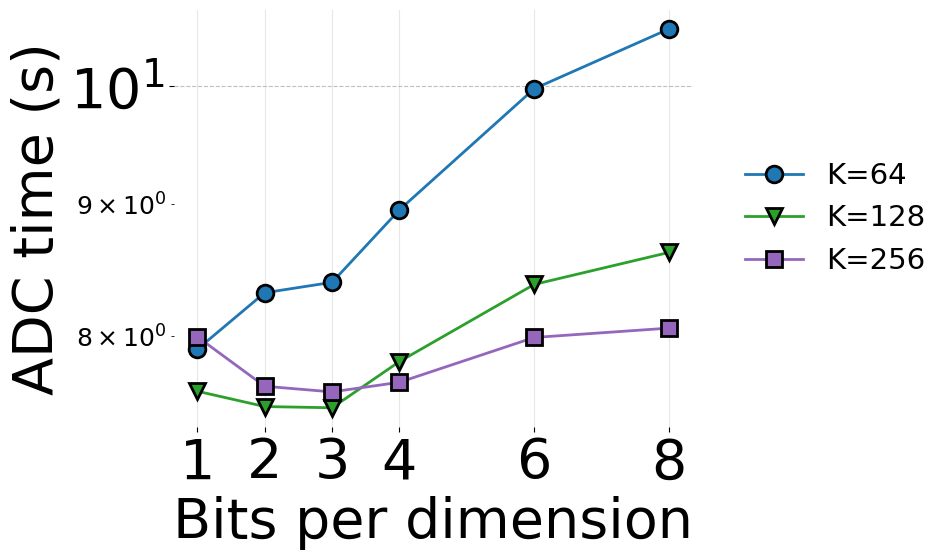

In [4]:
for metric_name in Y_METRICS:
    y_col, y_label = Y_METRIC_MAP[metric_name]
    for x_col, x_label in X_COLUMNS_TO_PLOT:
        if x_col not in plot_df.columns or y_col not in plot_df.columns:
            continue
        print("=" * 60)
        print(f"Plotting {y_label} vs {x_label}")
        print("=" * 60)
        plot_relerr_vs_x(
            plot_df,
            x_col=x_col,
            x_label=x_label,
            y_col=y_col,
            y_label=y_label,
            methods=METHODS_TO_PLOT,
            datasets=DATASETS_TO_PLOT,
            output_dir=FIGURES_DIR,
        )

for x_col, x_label, y_col, y_label, group_by in ADDITIONAL_PLOTS:
    if x_col not in plot_df.columns or y_col not in plot_df.columns:
        continue
    print("=" * 60)
    print(f"Plotting {y_label} vs {x_label} grouped by {group_by}")
    print("=" * 60)
    plot_relerr_vs_x(
        plot_df,
        x_col=x_col,
        x_label=x_label,
        y_col=y_col,
        y_label=y_label,
        methods=METHODS_TO_PLOT,
        datasets=DATASETS_TO_PLOT,
        group_by=group_by,
        output_dir=FIGURES_DIR,
    )


Average ADC time vs bits per dimension


Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_nbits_saq_deep10k.[pdf/svg]


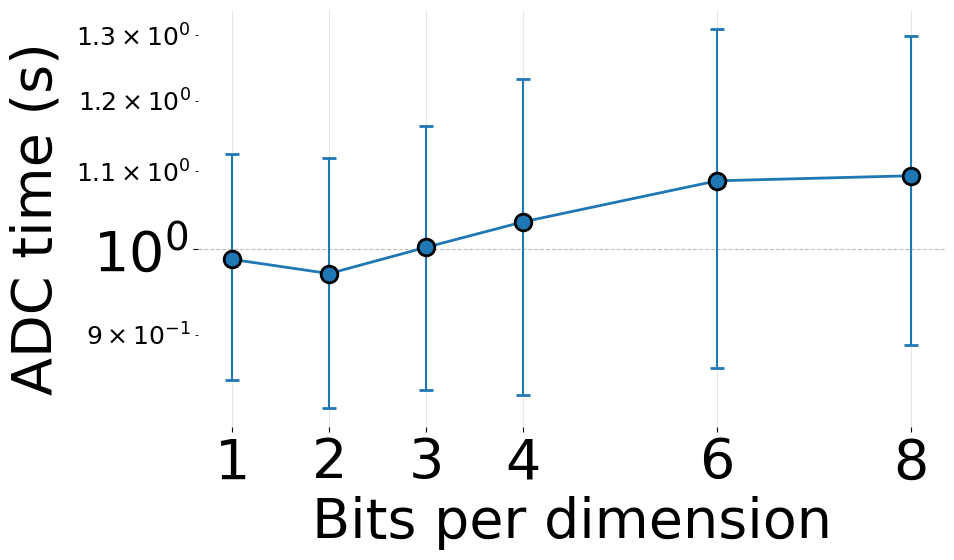

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_nbits_saq_bigann10k.[pdf/svg]


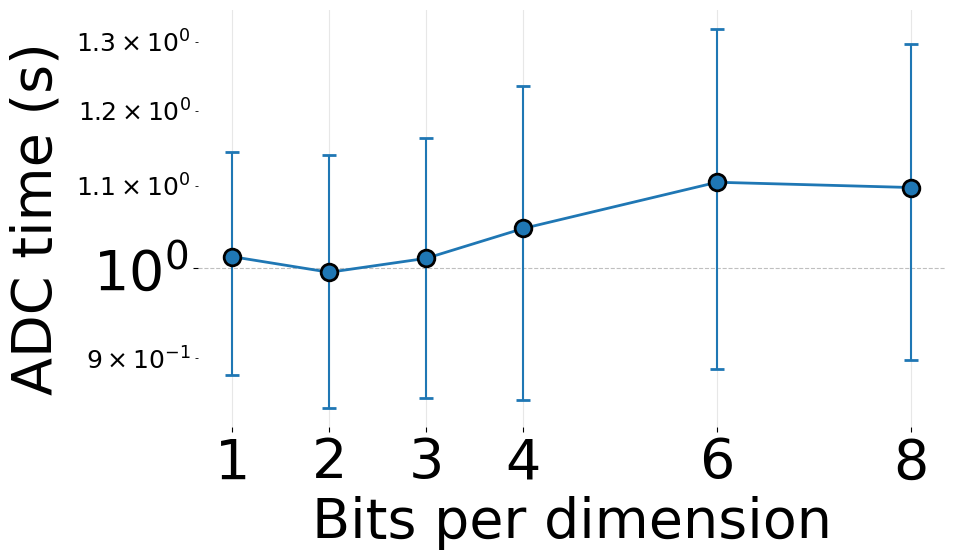

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_nbits_saq_gist10k.[pdf/svg]


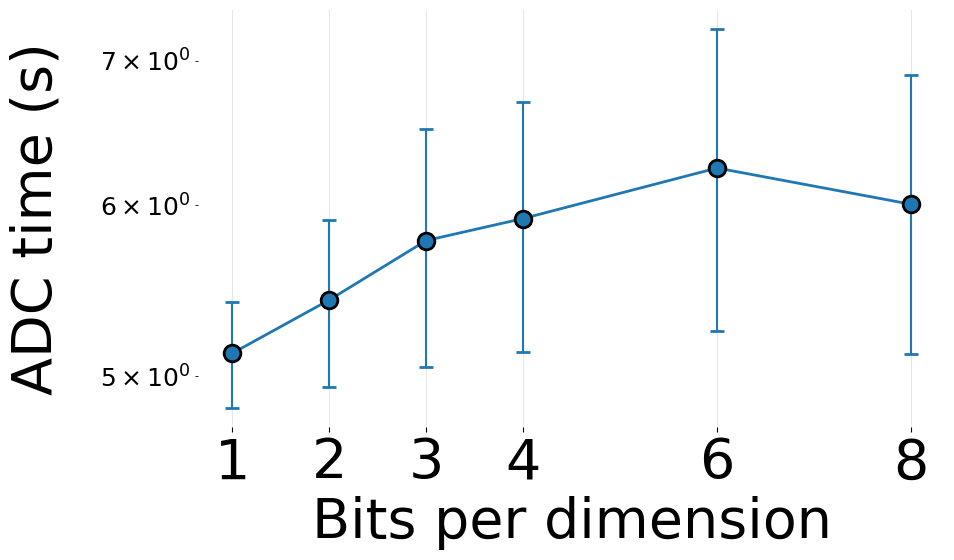

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_nbits_saq_msmarco10k.[pdf/svg]


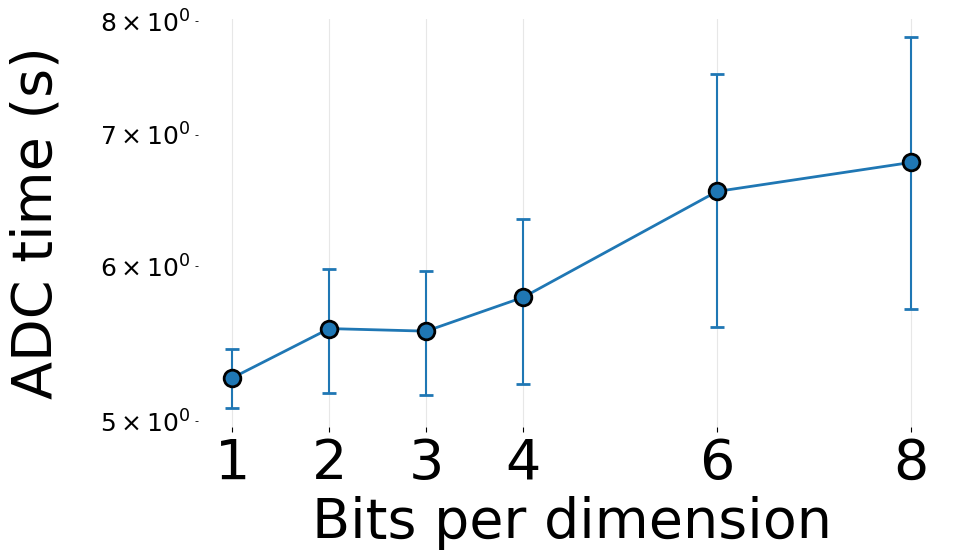

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_nbits_saq_openai10k.[pdf/svg]


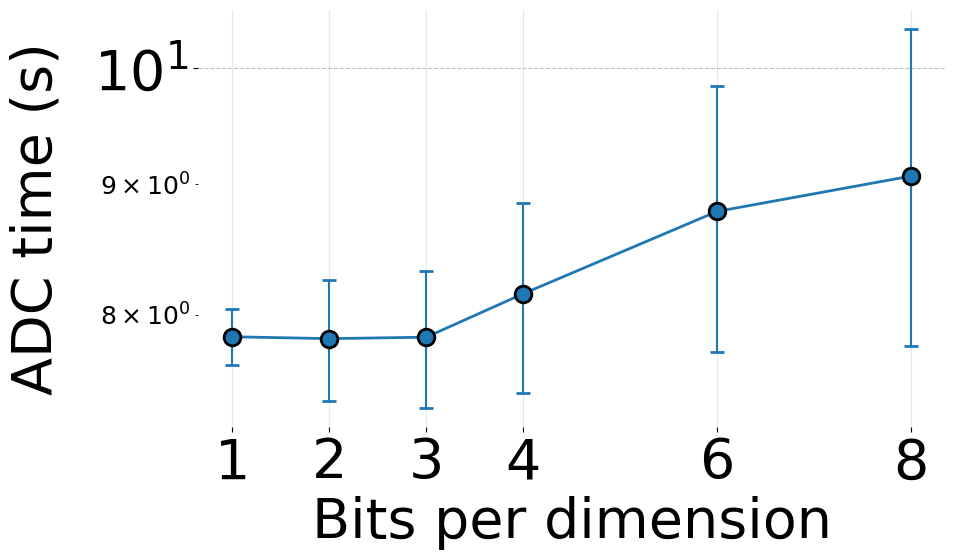

Average ADC time vs # of IVF centroids (K)
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_n_centroids_saq_deep10k.[pdf/svg]


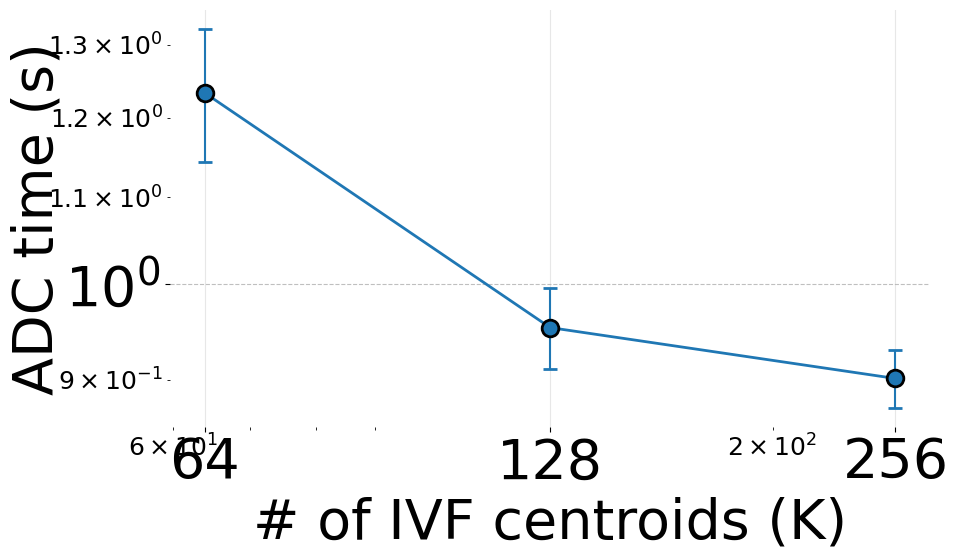

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_n_centroids_saq_bigann10k.[pdf/svg]


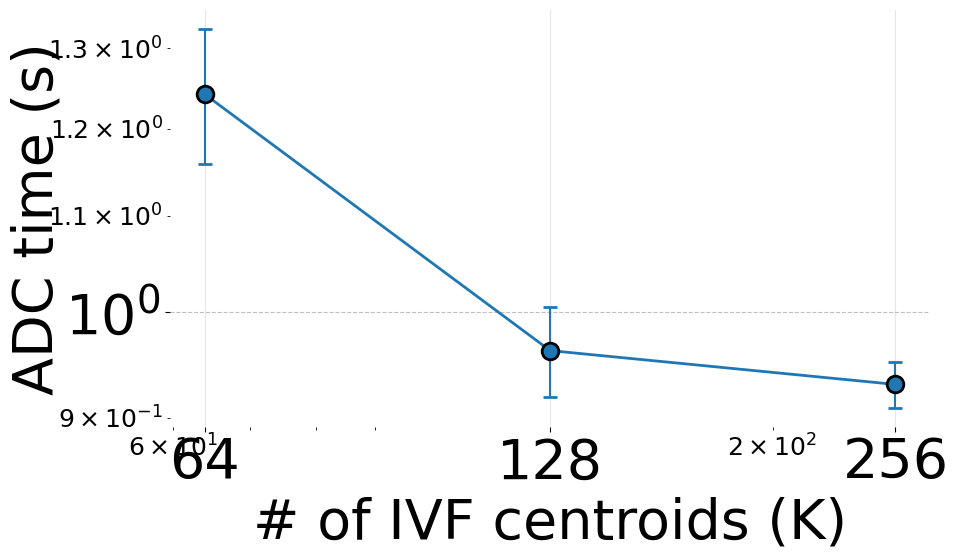

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_n_centroids_saq_gist10k.[pdf/svg]


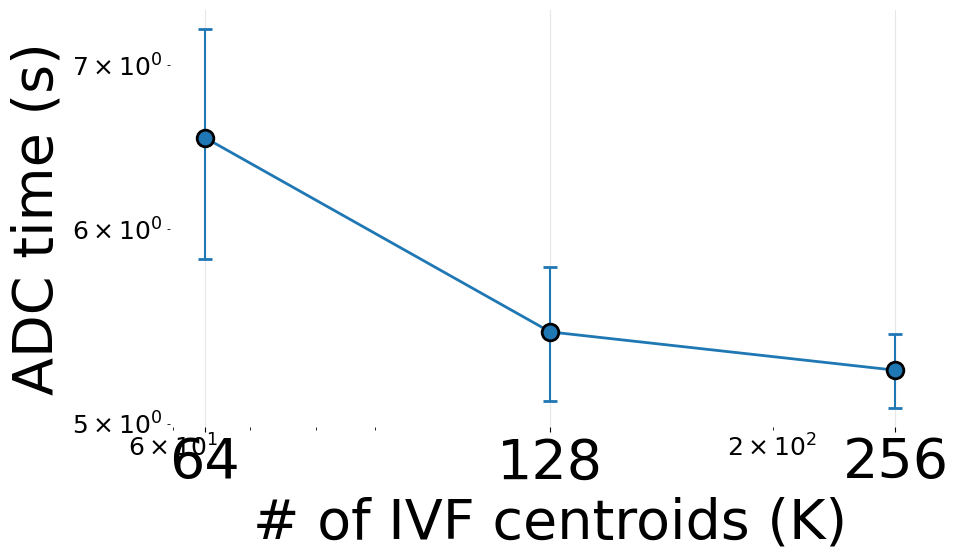

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_n_centroids_saq_msmarco10k.[pdf/svg]


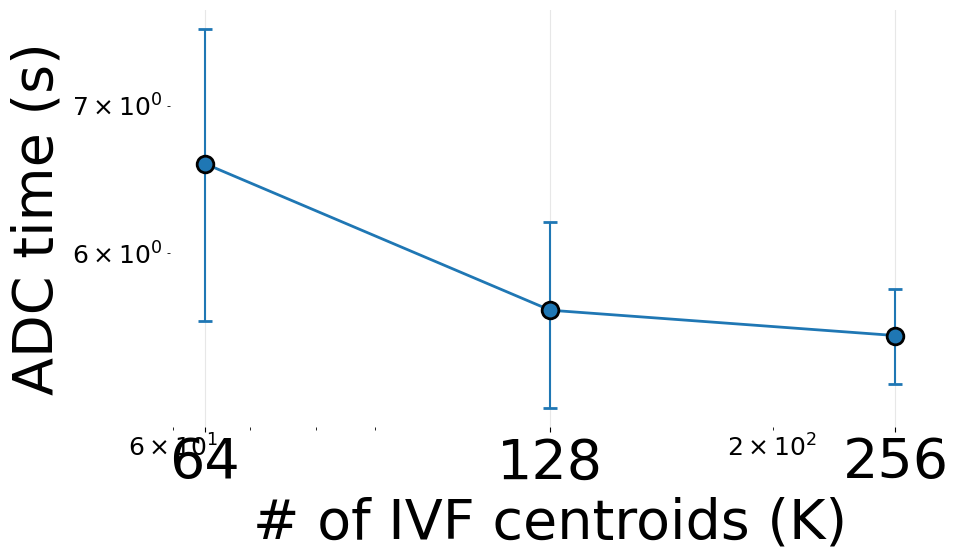

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/avg_adctimes_vs_n_centroids_saq_openai10k.[pdf/svg]


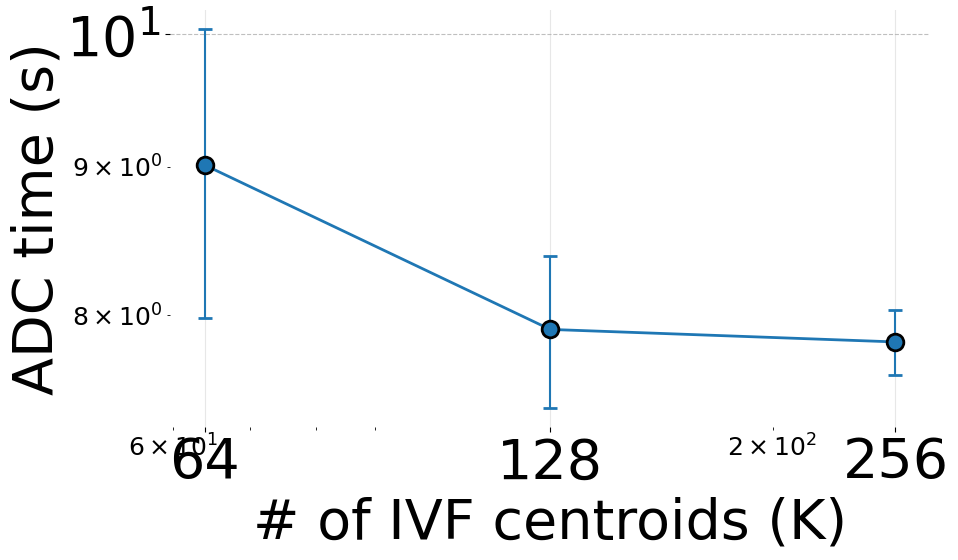

Pareto: ADC time vs Avg Relative Error (one point per bits per dimension)
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_nbits_saq_deep10k.[pdf/svg]


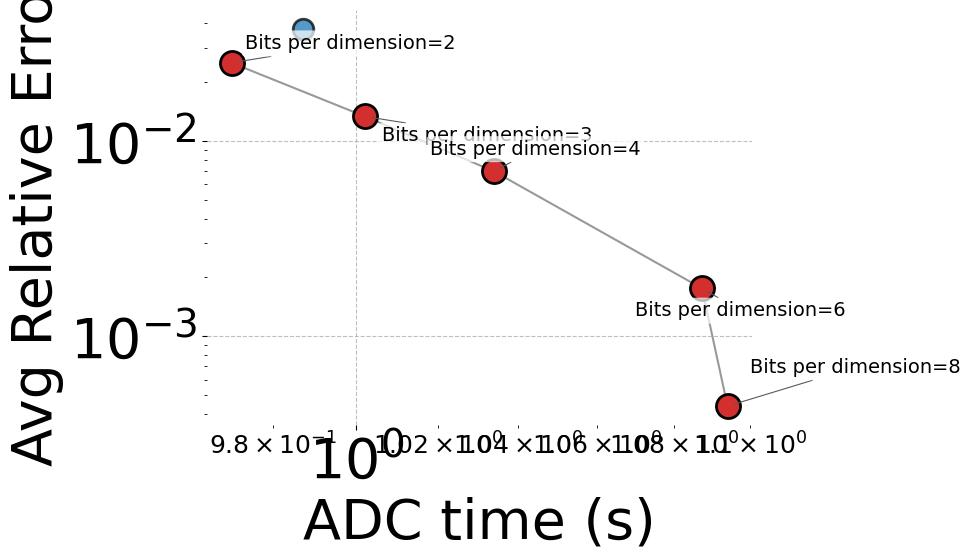

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_nbits_saq_bigann10k.[pdf/svg]


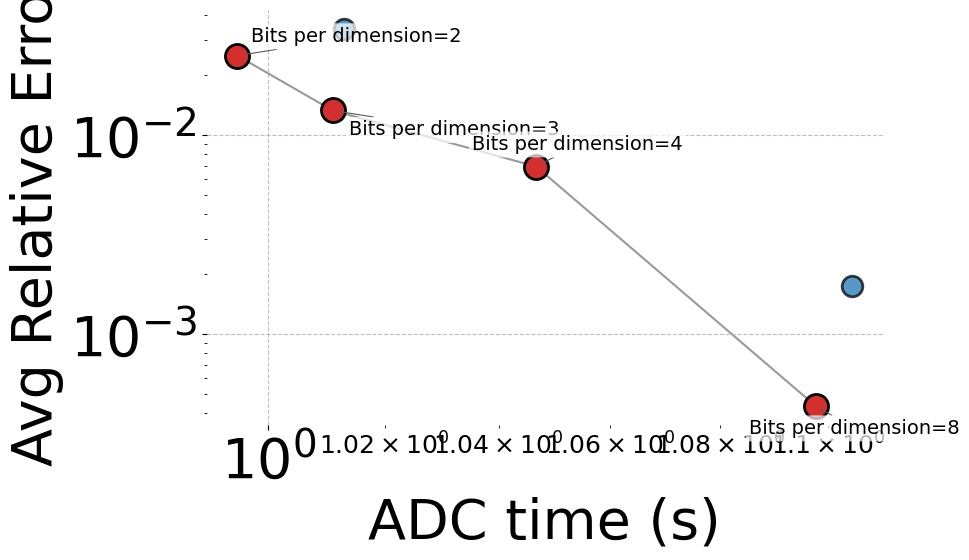

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_nbits_saq_gist10k.[pdf/svg]


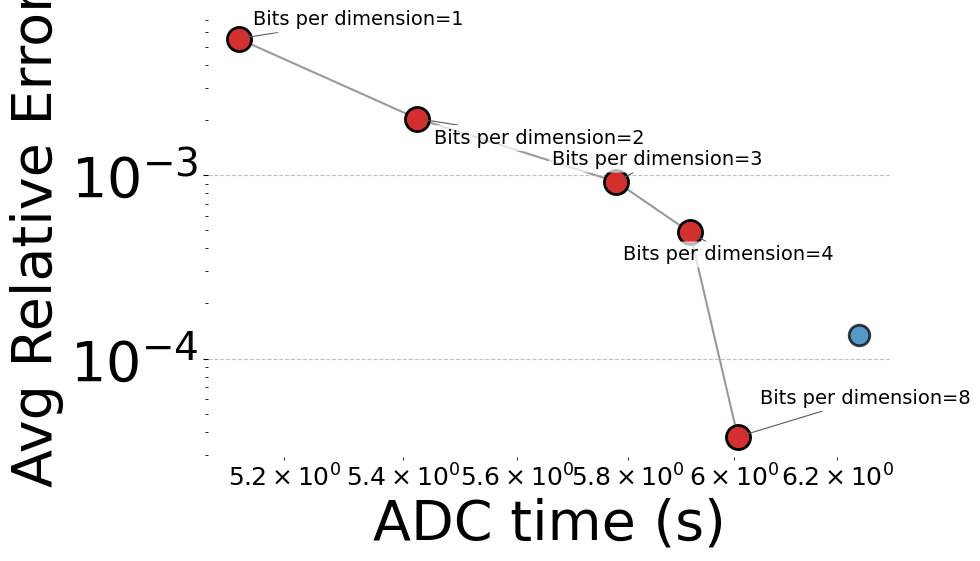

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_nbits_saq_msmarco10k.[pdf/svg]


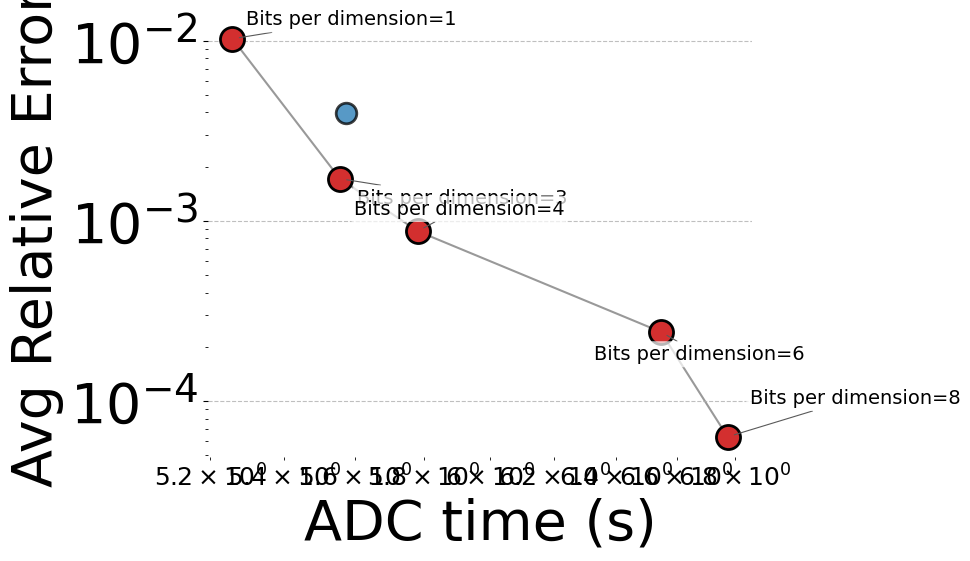

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_nbits_saq_openai10k.[pdf/svg]


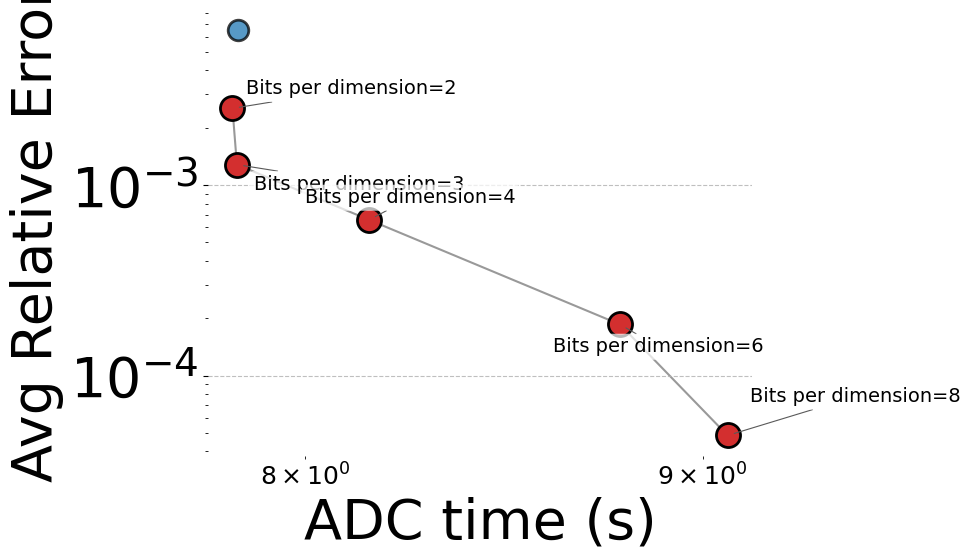

Pareto: ADC time vs Avg Relative Error (one point per K)
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_n_centroids_saq_deep10k.[pdf/svg]


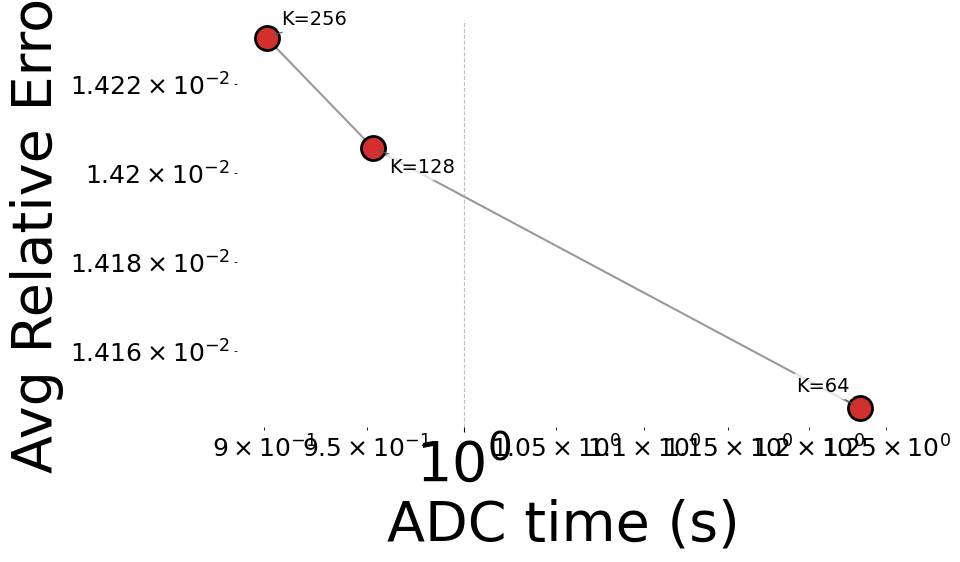

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_n_centroids_saq_bigann10k.[pdf/svg]


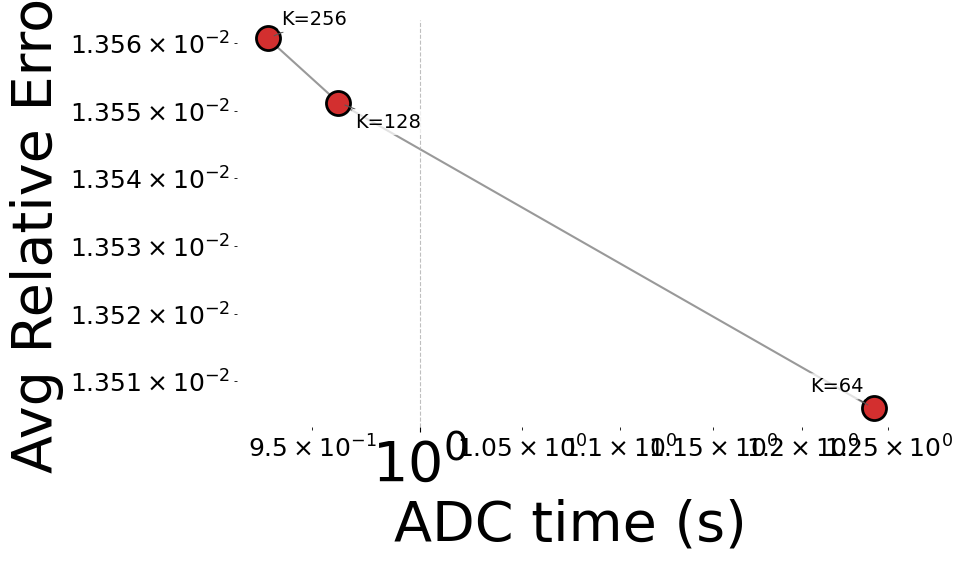

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_n_centroids_saq_gist10k.[pdf/svg]


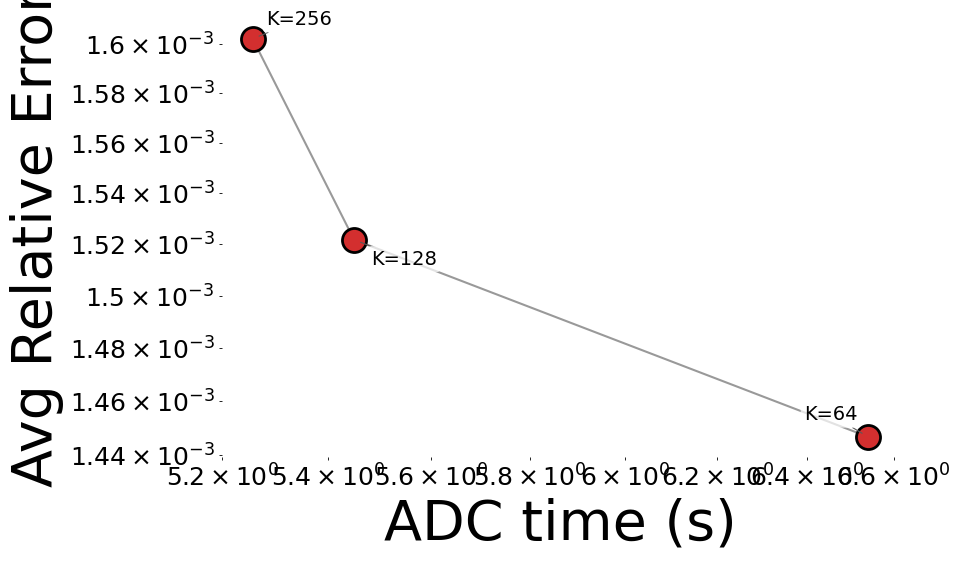

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_n_centroids_saq_msmarco10k.[pdf/svg]


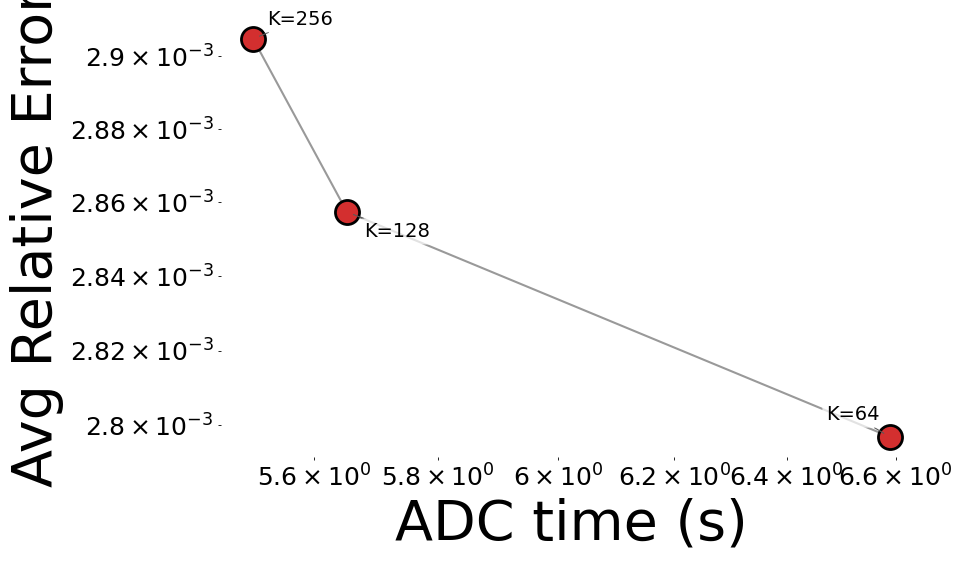

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_by_n_centroids_saq_openai10k.[pdf/svg]


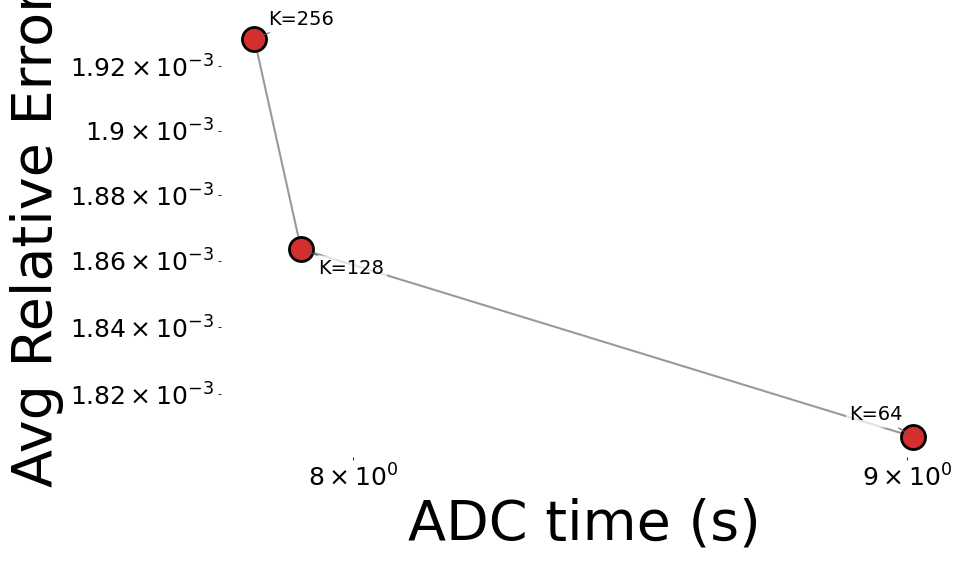

Pareto: ADC time vs Avg Relative Error (all K,bpd configurations)
Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_all_configs_saq_deep10k.[pdf/svg]


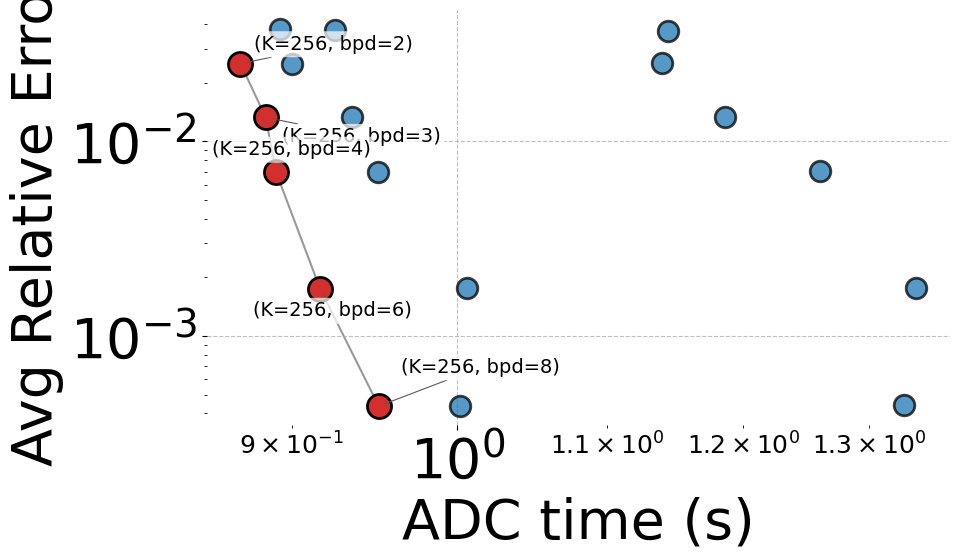

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_all_configs_saq_bigann10k.[pdf/svg]


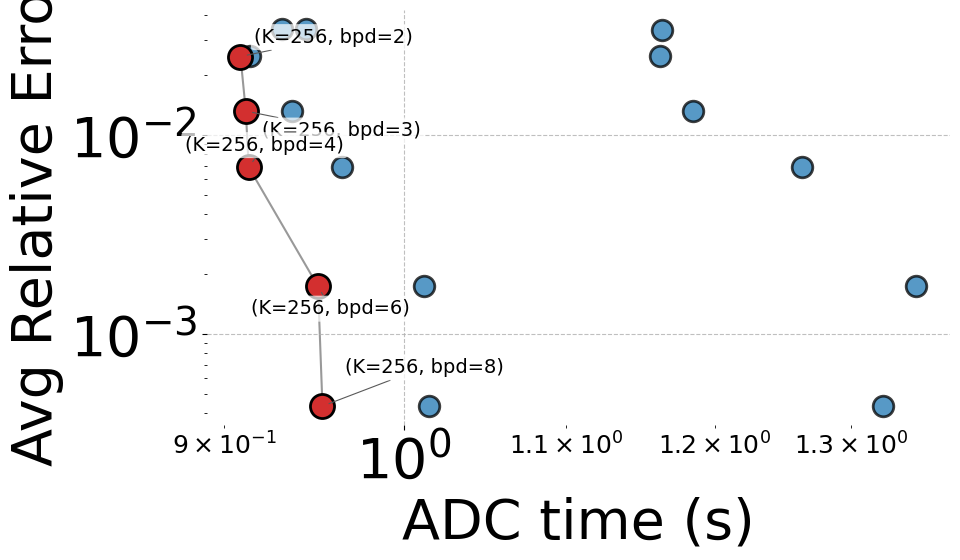

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_all_configs_saq_gist10k.[pdf/svg]


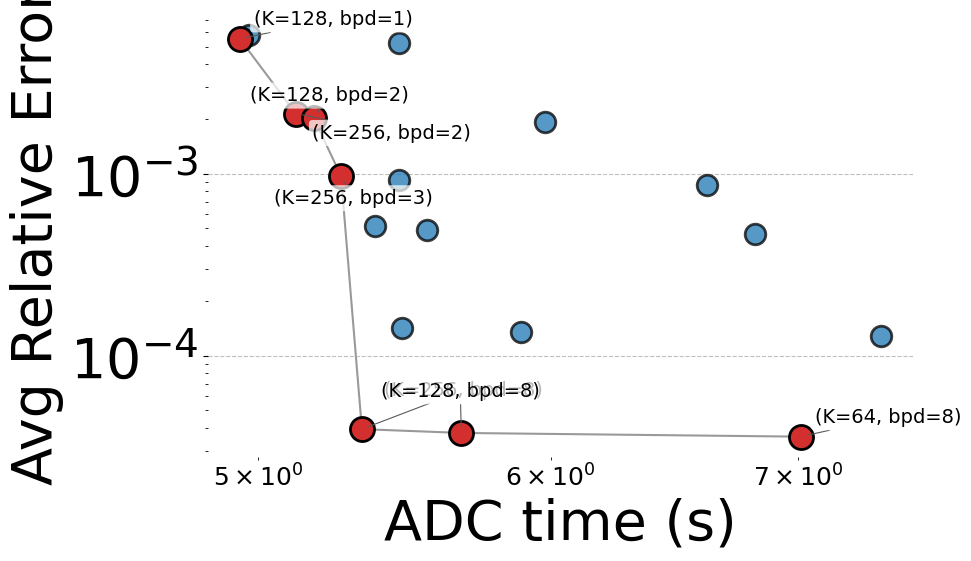

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_all_configs_saq_msmarco10k.[pdf/svg]


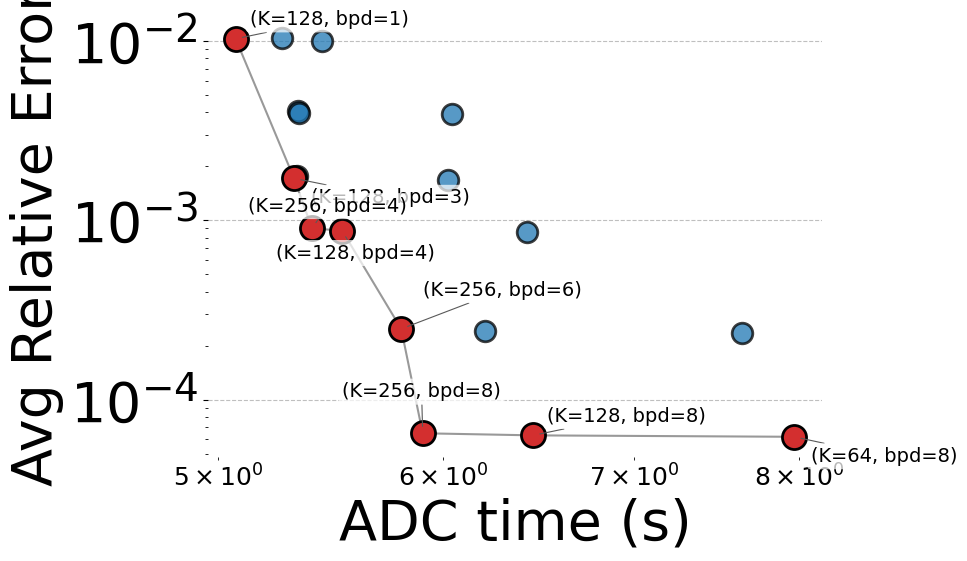

Saved /mnthdd/cpanourg/2-hdvc/results/saq_clean_timing/figures_cpp_style/pareto_adc_time_s_vs_rel_error_mean_all_configs_saq_openai10k.[pdf/svg]


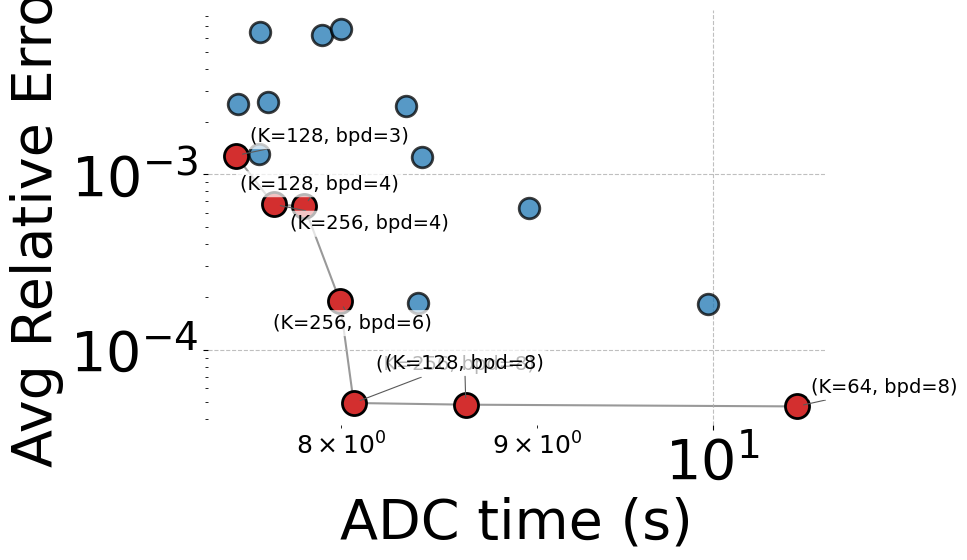

In [5]:
def pareto_frontier_minimize(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    pts = df.dropna(subset=[x_col, y_col]).sort_values([x_col, y_col]).copy()
    frontier = []
    best_y = np.inf
    for _, row in pts.iterrows():
        if row[y_col] < best_y:
            frontier.append(row)
            best_y = row[y_col]
    return pd.DataFrame(frontier) if frontier else pts.iloc[0:0]


def plot_averaged_adc_time(
    df: pd.DataFrame,
    x_col: str,
    x_label: str,
    y_col: str = ADC_TIME_COL,
    y_label: str = ADC_TIME_LABEL,
    methods: list = None,
    datasets: list = None,
    output_dir: Path = None,
):
    if methods is None:
        methods = sorted(df["method"].dropna().unique())
    if datasets is None:
        datasets = sorted(df["dataset"].dropna().unique())
    if output_dir is None:
        output_dir = FIGURES_DIR

    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].dropna(subset=[x_col, y_col]).copy()
            if sub.empty:
                continue
            agg = (
                sub.groupby(x_col)[y_col]
                .agg(["mean", "std"])
                .reset_index()
                .sort_values(x_col)
            )

            fig, ax = plt.subplots()
            ax.errorbar(
                agg[x_col], agg["mean"], yerr=agg["std"].fillna(0),
                fmt="o-", color=COLOR_PALETTE[0], markersize=12,
                linewidth=2, markeredgewidth=2, markeredgecolor="black",
                capsize=5, capthick=2, elinewidth=1.5,
            )
            ax.set_xlabel(x_label, fontsize=40)
            ax.set_ylabel(y_label, fontsize=40)
            ax.yaxis.set_label_coords(-0.18 if x_col == "nbits" else -0.14, 0.5)
            ax.set_yscale("log")
            if x_col == "n_centroids":
                ax.set_xscale("log")
                vals = sorted(agg[x_col].unique())
                _set_discrete_xticks(ax, vals)
            else:
                vals = sorted(agg[x_col].unique())
                _set_discrete_xticks(ax, vals, fontsize=30)

            set_sci_axes(ax, tick_fontsize=40, offset_fontsize=30)
            ax.grid(alpha=0.8, axis="y", linestyle="--")
            for spine in ax.spines.values():
                spine.set_visible(False)
            plt.tight_layout()
            savepath = output_dir / f"avg_{y_col.replace('_', '')}_vs_{x_col}_{method.lower()}_{dataset}.pdf"
            _save_figure(fig, savepath)
            plt.show()
            plt.close(fig)


def plot_pareto_adc_vs_relerr_all_configs(
    df: pd.DataFrame,
    x_col: str = ADC_TIME_COL,
    y_col: str = "rel_error_mean",
    x_label: str = ADC_TIME_LABEL,
    y_label: str = "Avg Relative Error",
    methods: list = None,
    datasets: list = None,
    output_dir: Path = None,
):
    if methods is None:
        methods = sorted(df["method"].dropna().unique())
    if datasets is None:
        datasets = sorted(df["dataset"].dropna().unique())
    if output_dir is None:
        output_dir = FIGURES_DIR

    for method in methods:
        for dataset in datasets:
            pts = df[(df["method"] == method) & (df["dataset"] == dataset)].dropna(
                subset=["n_centroids", "nbits", x_col, y_col]
            ).sort_values([x_col, y_col, "n_centroids", "nbits"]).copy()
            if pts.empty:
                continue

            frontier = pareto_frontier_minimize(pts, x_col, y_col)

            fig, ax = plt.subplots()
            ax.scatter(
                pts[x_col],
                pts[y_col],
                color="tab:blue",
                marker="o",
                s=220,
                edgecolors="black",
                linewidths=2,
                alpha=0.75,
                zorder=2,
            )

            if not frontier.empty:
                ax.plot(
                    frontier[x_col],
                    frontier[y_col],
                    "-",
                    color="gray",
                    linewidth=1.5,
                    alpha=0.8,
                    zorder=1,
                )
                ax.scatter(
                    frontier[x_col],
                    frontier[y_col],
                    color="#D32F2F",
                    marker="o",
                    s=300,
                    edgecolors="black",
                    linewidths=2,
                    zorder=3,
                )

                offsets = [(10, 10), (12, -18), (-46, 12), (-48, -20), (16, 24), (-58, 26)]
                for i, (_, row) in enumerate(frontier.iterrows()):
                    ax.annotate(
                        f"(K={_format_tick_value(row['n_centroids'])}, {BPD_SHORT_LABEL}={_format_tick_value(row['nbits'])})",
                        (row[x_col], row[y_col]),
                        xytext=offsets[i % len(offsets)],
                        textcoords="offset points",
                        fontsize=14,
                        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.72),
                        arrowprops=dict(arrowstyle="-", color="0.35", lw=0.8, shrinkA=0, shrinkB=5),
                    )

            ax.set_xlabel(x_label, fontsize=40)
            ax.set_ylabel(y_label, fontsize=40)
            ax.set_xscale("log")
            if (pts[y_col] > 0).all():
                ax.set_yscale("log")
            set_sci_axes(ax, tick_fontsize=40, offset_fontsize=30)
            ax.grid(alpha=0.8, axis="both", linestyle="--")
            for spine in ax.spines.values():
                spine.set_visible(False)
            plt.tight_layout()
            savepath = output_dir / f"pareto_{x_col}_vs_{y_col}_all_configs_{method.lower()}_{dataset}.pdf"
            _save_figure(fig, savepath)
            plt.show()
            plt.close(fig)


def plot_pareto_adc_vs_relerr(
    df: pd.DataFrame,
    group_col: str,
    group_label: str,
    x_col: str = ADC_TIME_COL,
    y_col: str = "rel_error_mean",
    x_label: str = ADC_TIME_LABEL,
    y_label: str = "Avg Relative Error",
    methods: list = None,
    datasets: list = None,
    output_dir: Path = None,
):
    if methods is None:
        methods = sorted(df["method"].dropna().unique())
    if datasets is None:
        datasets = sorted(df["dataset"].dropna().unique())
    if output_dir is None:
        output_dir = FIGURES_DIR

    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].dropna(subset=[group_col, x_col, y_col]).copy()
            if sub.empty:
                continue

            agg = (
                sub.groupby(group_col)[[x_col, y_col]]
                .mean()
                .reset_index()
                .sort_values(group_col)
            )
            if agg.empty:
                continue

            frontier = pareto_frontier_minimize(agg, x_col, y_col)

            fig, ax = plt.subplots()
            ax.scatter(
                agg[x_col],
                agg[y_col],
                color="tab:blue",
                marker="o",
                s=220,
                edgecolors="black",
                linewidths=2,
                alpha=0.75,
                zorder=2,
            )

            if not frontier.empty:
                ax.plot(
                    frontier[x_col],
                    frontier[y_col],
                    "-",
                    color="gray",
                    linewidth=1.5,
                    alpha=0.8,
                    zorder=1,
                )
                ax.scatter(
                    frontier[x_col],
                    frontier[y_col],
                    color="#D32F2F",
                    marker="o",
                    s=300,
                    edgecolors="black",
                    linewidths=2,
                    zorder=3,
                )

                offsets = [(10, 10), (12, -18), (-46, 12), (-48, -20), (16, 24), (-58, 26)]
                for i, (_, row) in enumerate(frontier.iterrows()):
                    group_val = row[group_col]
                    ax.annotate(
                        f"{group_label}={_format_tick_value(group_val)}",
                        (row[x_col], row[y_col]),
                        xytext=offsets[i % len(offsets)],
                        textcoords="offset points",
                        fontsize=14,
                        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.72),
                        arrowprops=dict(arrowstyle="-", color="0.35", lw=0.8, shrinkA=0, shrinkB=5),
                    )

            ax.set_xlabel(x_label, fontsize=40)
            ax.set_ylabel(y_label, fontsize=40)
            ax.set_xscale("log")
            if (agg[y_col] > 0).all():
                ax.set_yscale("log")
            set_sci_axes(ax, tick_fontsize=40, offset_fontsize=30)
            ax.grid(alpha=0.8, axis="both", linestyle="--")
            for spine in ax.spines.values():
                spine.set_visible(False)
            plt.tight_layout()
            savepath = output_dir / f"pareto_{x_col}_vs_{y_col}_by_{group_col}_{method.lower()}_{dataset}.pdf"
            _save_figure(fig, savepath)
            plt.show()
            plt.close(fig)


print("=" * 60)
print("Average ADC time vs bits per dimension")
print("=" * 60)
plot_averaged_adc_time(
    plot_df,
    x_col="nbits",
    x_label=NBITS_LABEL,
    methods=METHODS_TO_PLOT,
    datasets=DATASETS_TO_PLOT,
    output_dir=FIGURES_DIR,
)

print("=" * 60)
print("Average ADC time vs # of IVF centroids (K)")
print("=" * 60)
plot_averaged_adc_time(
    plot_df,
    x_col="n_centroids",
    x_label="# of IVF centroids (K)",
    methods=METHODS_TO_PLOT,
    datasets=DATASETS_TO_PLOT,
    output_dir=FIGURES_DIR,
)

print("=" * 60)
print("Pareto: ADC time vs Avg Relative Error (one point per bits per dimension)")
print("=" * 60)
plot_pareto_adc_vs_relerr(
    plot_df,
    group_col="nbits",
    group_label=NBITS_LABEL,
    methods=METHODS_TO_PLOT,
    datasets=DATASETS_TO_PLOT,
    output_dir=FIGURES_DIR,
)

print("=" * 60)
print("Pareto: ADC time vs Avg Relative Error (one point per K)")
print("=" * 60)
plot_pareto_adc_vs_relerr(
    plot_df,
    group_col="n_centroids",
    group_label="K",
    methods=METHODS_TO_PLOT,
    datasets=DATASETS_TO_PLOT,
    output_dir=FIGURES_DIR,
)

print("=" * 60)
print("Pareto: ADC time vs Avg Relative Error (all K,bpd configurations)")
print("=" * 60)
plot_pareto_adc_vs_relerr_all_configs(
    plot_df,
    methods=METHODS_TO_PLOT,
    datasets=DATASETS_TO_PLOT,
    output_dir=FIGURES_DIR,
)
